# **Séries Temporelles**

## Télécharger les packages

In [1]:
%%capture
!pip3 install eurostat numpy pandas matplotlib statsmodels seaborn

## Mobilisation des packages

In [2]:
import eurostat
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path
from matplotlib import gridspec
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import acf, pacf, grangercausalitytests

## Chemin d'accès

In [3]:
FIGURE_DIR = Path("../figure")
TABLE_DIR = Path("../table")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# PARTIE 1 : 
## Récupérer les données issus d'Eurostat

### Série Exportation (X)

In [4]:
X = eurostat.get_data_df("namq_10_exi")
X = X[
    (X["unit"] == "CLV10_MEUR")
    & (X["na_item"] == "P6")
    & (X["s_adj"] == "SCA")
    & (X[r"geo\TIME_PERIOD"] == "LU")
]
X = X.dropna(axis=1)
X = X.iloc[:, 5:]
X = X.T
X = X.rename(columns={X.columns[0]: "X"})
X = np.log(X)
X = X.head(120)

# Version en différence de la série exportation
X_diff = X.diff().dropna()

### Série Importation (M)

In [5]:
M = eurostat.get_data_df("namq_10_exi")
M = M[
    (M["unit"] == "CLV10_MEUR")
    & (M["na_item"] == "P7")
    & (M["s_adj"] == "SCA")
    & (M[r"geo\TIME_PERIOD"] == "LU")
]
M = M.dropna(axis=1)
M = M.iloc[:, 5:]
M = M.T
M = M.rename(columns={M.columns[0]: "M"})
M = np.log(M)
M = M.head(120)

# Version en différence de la série importation
M_diff = M.diff().dropna()

## Exportation vers Excel

In [6]:
X.to_excel(TABLE_DIR / "x-level.xlsx", index=False)

In [7]:
M.to_excel(TABLE_DIR / "m-level.xlsx", index=False)

## Graphiques

### Pour le tableau de la FAC et FAP

In [8]:
X_fac = acf(
    X,
    adjusted=0,
    nlags=32,
    qstat=True,
    fft=True,
    alpha=None,
    bartlett_confint=True,
    missing="none",
)
XT = pd.DataFrame(X_fac).T.rename(columns={0: "FAC", 1: "Q-stat", 2: "Prob"})
X_fap = pacf(X, nlags=32, method="ywmle", alpha=None)
XTFAP = (
    pd.DataFrame(X_fap).iloc[1:, :].reset_index(drop=True).rename(columns={0: "FAP"})
)
XT.insert(1, "FAP", XTFAP)
XT.iloc[:, 0] = XT.iloc[:, 0].shift(-1)
XT = XT.drop(XT.index[-1]).reset_index(drop=True)

XT[["FAC", "FAP", "Prob"]] = XT[["FAC", "FAP", "Prob"]].round(3)

XT[["Q-stat"]] = XT[["Q-stat"]].round(2)

XT.insert(0, "Lag", range(1, len(XT) + 1))

XT.to_excel(TABLE_DIR / "facfap-x-level.xlsx", index=False)

In [9]:
X_fac = acf(
    X_diff,
    adjusted=0,
    nlags=32,
    qstat=True,
    fft=True,
    alpha=None,
    bartlett_confint=True,
    missing="none",
)
XTD = pd.DataFrame(X_fac).T.rename(columns={0: "FAC", 1: "Q-stat", 2: "Prob"})
X_fap = pacf(X_diff, nlags=32, method="ywmle", alpha=None)
XTDFAP = (
    pd.DataFrame(X_fap).iloc[1:, :].reset_index(drop=True).rename(columns={0: "FAP"})
)
XTD.insert(1, "FAP", XTDFAP)
XTD.iloc[:, 0] = XTD.iloc[:, 0].shift(-1)
XTD = XTD.drop(XTD.index[-1]).reset_index(drop=True)

XTD[["FAC", "FAP", "Prob"]] = XTD[["FAC", "FAP", "Prob"]].round(3)

XTD[["Q-stat"]] = XTD[["Q-stat"]].round(2)

XTD.insert(0, "Lag", range(1, len(XTD) + 1))


XTD.to_excel(TABLE_DIR / "facfap-x-diff.xlsx", index=False)

In [10]:
M_fac = acf(
    M,
    adjusted=0,
    nlags=32,
    qstat=True,
    fft=True,
    alpha=None,
    bartlett_confint=True,
    missing="none",
)
MT = pd.DataFrame(M_fac).T.rename(columns={0: "FAC", 1: "Q-stat", 2: "Prob"})
M_fap = pacf(M, nlags=32, method="ywmle", alpha=None)
MTFAP = (
    pd.DataFrame(M_fap).iloc[1:, :].reset_index(drop=True).rename(columns={0: "FAP"})
)
MT.insert(1, "FAP", MTFAP)
MT.iloc[:, 0] = MT.iloc[:, 0].shift(-1)
MT = MT.drop(MT.index[-1]).reset_index(drop=True)

MT[["FAC", "FAP", "Prob"]] = MT[["FAC", "FAP", "Prob"]].round(3)

MT[["Q-stat"]] = MT[["Q-stat"]].round(2)

MT.insert(0, "Lag", range(1, len(MT) + 1))

MT.to_excel(TABLE_DIR / "facfap-m-level.xlsx", index=False)

In [11]:
M_fac = acf(
    M_diff,
    adjusted=0,
    nlags=32,
    qstat=True,
    fft=True,
    alpha=None,
    bartlett_confint=True,
    missing="none",
)
MTD = pd.DataFrame(M_fac).T.rename(columns={0: "FAC", 1: "Q-stat", 2: "Prob"})
M_fap = pacf(M_diff, nlags=32, method="ywmle", alpha=None)
MTDFAP = (
    pd.DataFrame(M_fap).iloc[1:, :].reset_index(drop=True).rename(columns={0: "FAP"})
)
MTD.insert(1, "FAP", MTDFAP)
MTD.iloc[:, 0] = MTD.iloc[:, 0].shift(-1)
MTD = MTD.drop(MTD.index[-1]).reset_index(drop=True)

MTD[["FAC", "FAP", "Prob"]] = MTD[["FAC", "FAP", "Prob"]].round(3)

MTD[["Q-stat"]] = MTD[["Q-stat"]].round(2)

MTD.insert(0, "Lag", range(1, len(MTD) + 1))

MTD.to_excel(TABLE_DIR / "facfap-m-diff.xlsx", index=False)

### Transformation des données des deux séries pour le graphique

In [12]:
XM = pd.concat([X] + [M], axis=1)
XM = XM.rename(columns={"X": "lnX", "M": "lnM"})
XM.index = pd.date_range(start="1995-01-01", periods=120, freq="QS")
XM.index = pd.to_datetime(XM.index)

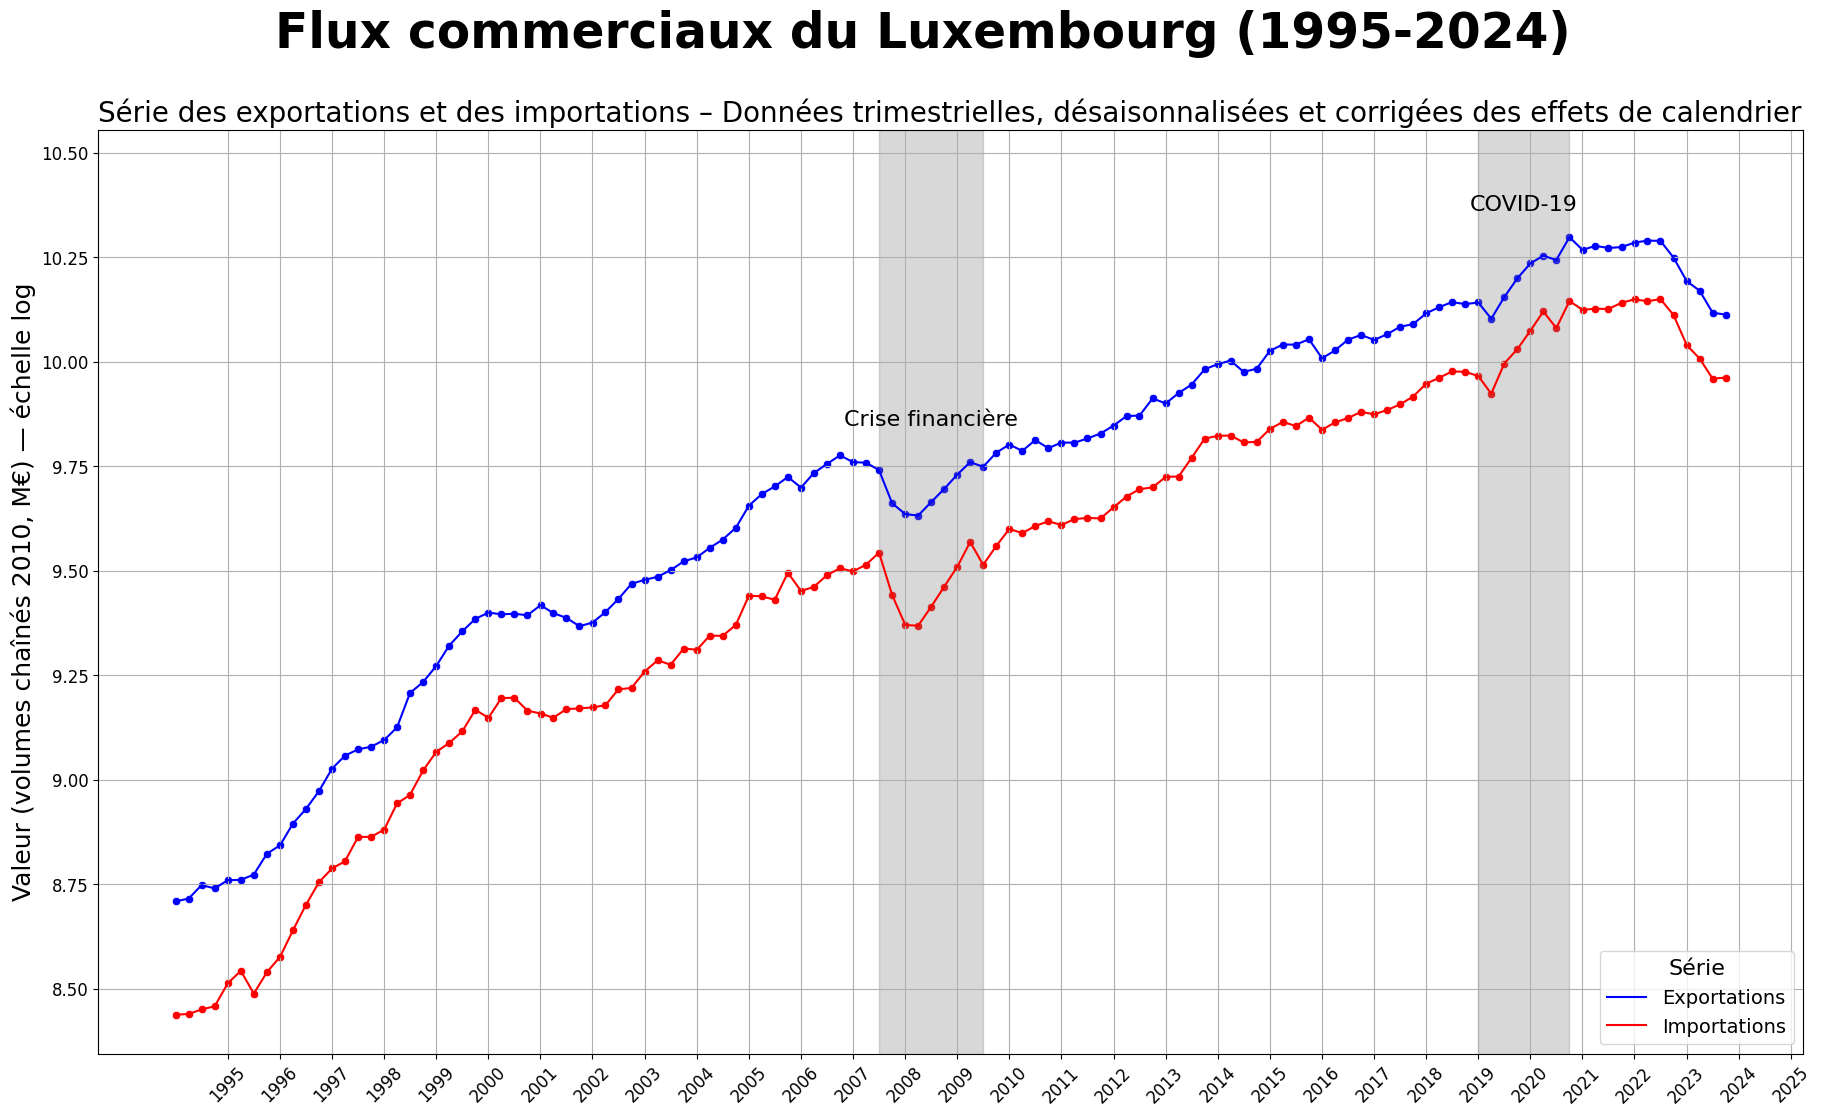

In [13]:
# Création de la figure et des axes
plt.figure(figsize=(22, 12))

# Tracé des courbes
sns.lineplot(data=XM, x=XM.index, y="lnX", color="blue", label="Exportations")
sns.scatterplot(data=XM, x=XM.index, y="lnX", color="blue")

sns.lineplot(data=XM, x=XM.index, y="lnM", color="red", label="Importations")
sns.scatterplot(data=XM, x=XM.index, y="lnM", color="red")

plt.ylim(top=XM[["lnX", "lnM"]].max().max() * 1.025)

# Zones grisées pour les crises
crise_fin_start = pd.Timestamp("2008-07-01")
crise_fin_end = pd.Timestamp("2010-06-30")
covid_start = pd.Timestamp("2020-01-01")
covid_end = pd.Timestamp("2021-09-30")

plt.axvspan(crise_fin_start, crise_fin_end, color="grey", alpha=0.3)
plt.axvspan(covid_start, covid_end, color="grey", alpha=0.3)

# Annotation des crises
plt.text(
    x=crise_fin_start + (crise_fin_end - crise_fin_start) / 2,
    y=XM[["lnX", "lnM"]].max().max() * 0.96,
    s="Crise financière",
    fontsize=16,
    ha="center",
    va="top",
    color="black",
)

plt.text(
    x=covid_start + (covid_end - covid_start) / 2,
    y=XM[["lnX", "lnM"]].max().max() * 1.01,
    s="COVID-19",
    fontsize=16,
    ha="center",
    va="top",
    color="black",
)

# Ajout du titre et des labels
plt.xlabel(None)
plt.ylabel("Valeur (volumes chaînés 2010, M€) — échelle log", fontsize=18)
plt.title(
    "Série des exportations et des importations – Données trimestrielles, désaisonnalisées et corrigées des effets de calendrier",
    fontsize=20,
    loc="left",
)
plt.suptitle(
    "Flux commerciaux du Luxembourg (1995-2024)", fontsize=35, fontweight="bold"
)

# Légende
plt.legend(
    title="Série",
    title_fontsize=16,
    fontsize=14,
    loc="lower right",
    bbox_to_anchor=(1, 0),
)

plt.grid(True)

# Personnalisation des axes
plt.xticks(pd.date_range(start="1995", periods=31, freq="YE"), fontsize=12, rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.yticks(fontsize=12)

# Affichage
plt.savefig(FIGURE_DIR / "01-flux-commerciaux-1995-2024.png", bbox_inches="tight")
plt.show()

### FAC et FAP (niveau et différence)

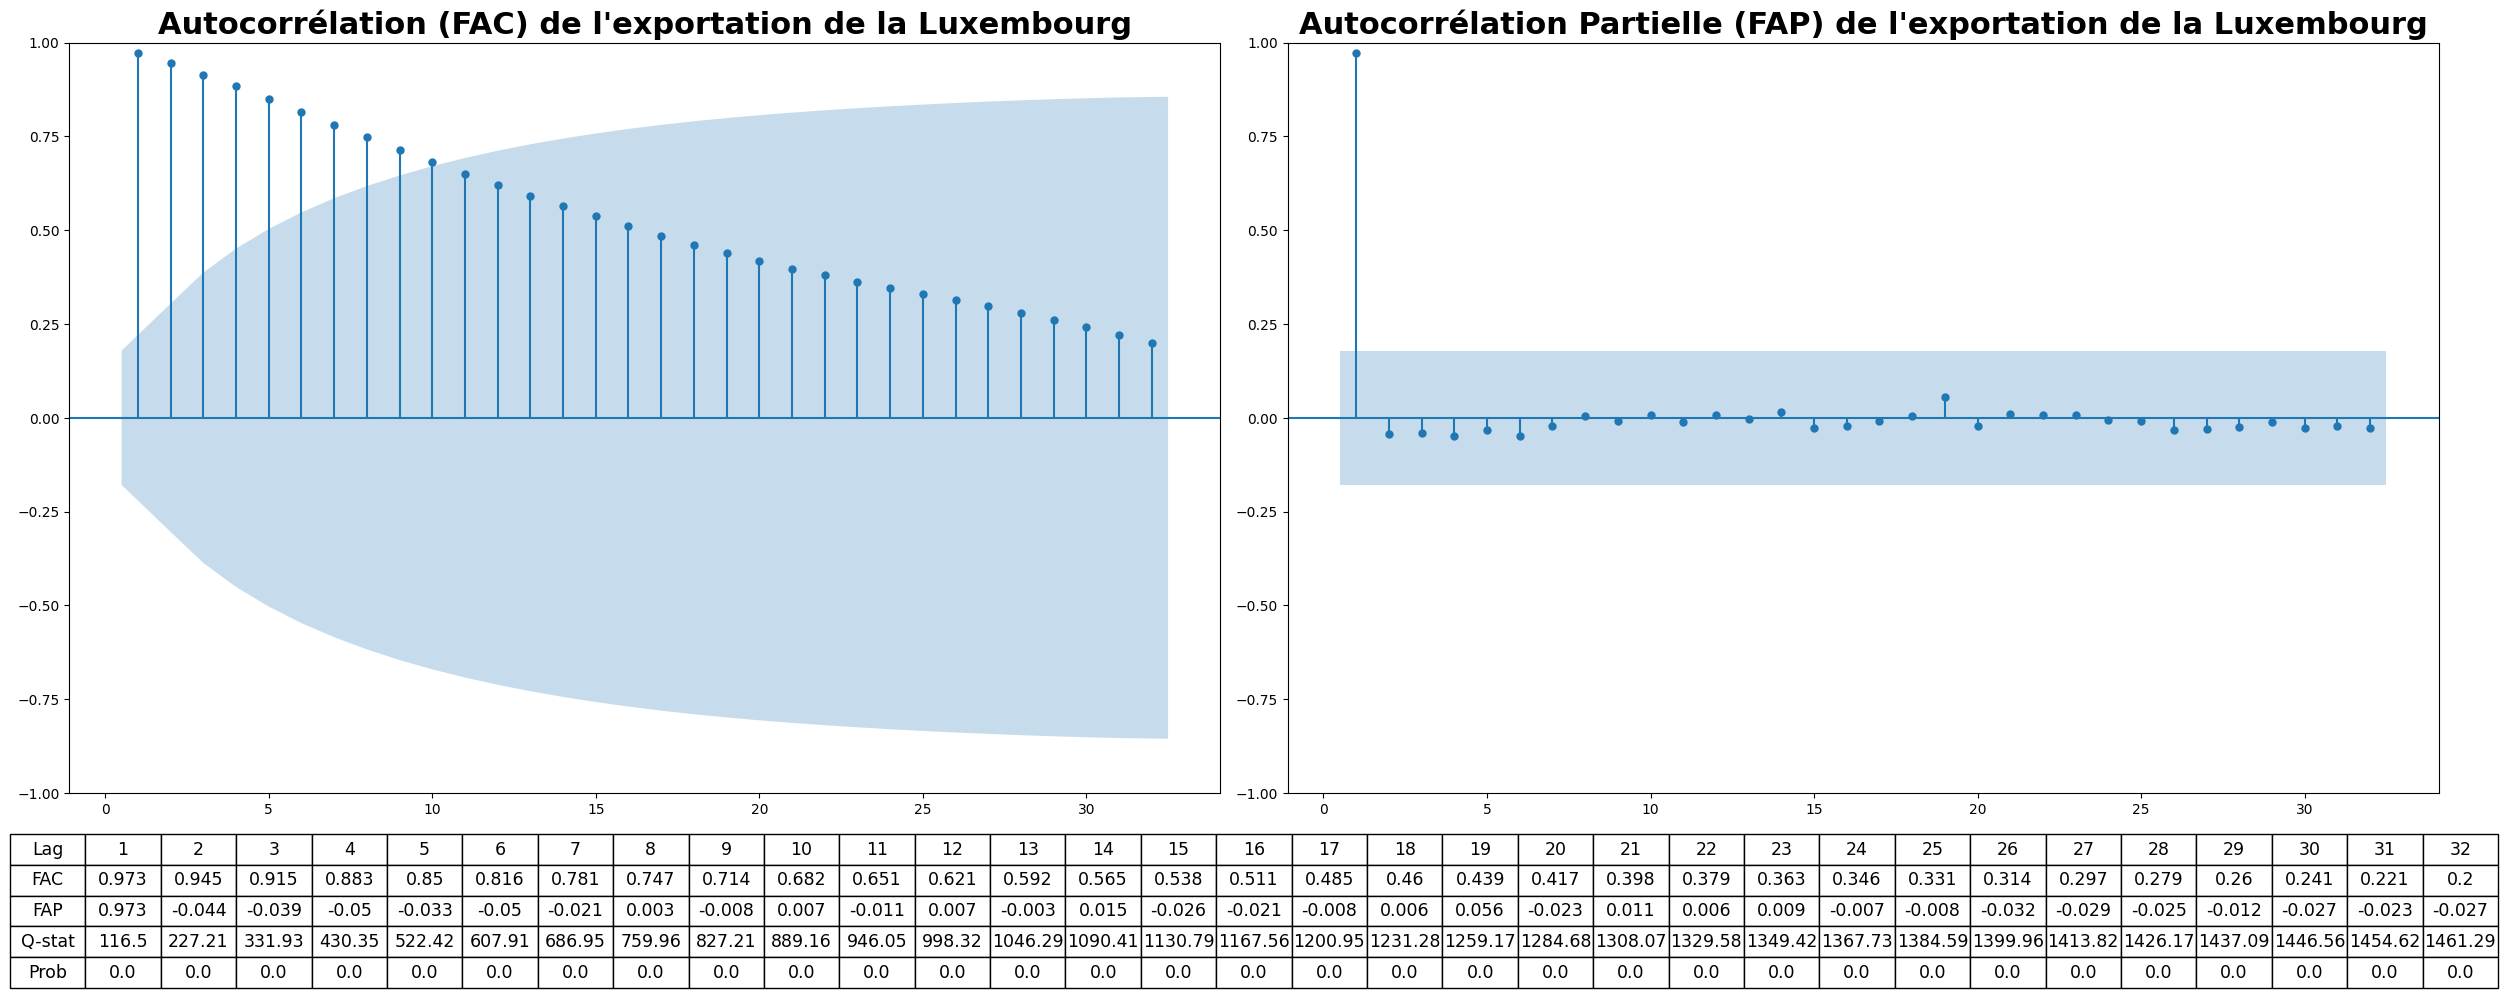

In [14]:
XG = XT.set_index("Lag").T
XG = XG.reset_index().rename(
    columns={"index": "Lag"}
)  # Important pour afficher FAC/FAP/etc
# Créer la figure avec GridSpec
fig = plt.figure(figsize=(25, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 3])
# Graphiques
ax0 = fig.add_subplot(gs[0, 0])
sm.graphics.tsa.plot_acf(
    X,
    lags=32,
    zero=False,
    title="Autocorrélation (FAC) de l'exportation de la Luxembourg",
    ax=ax0,
)
ax0.set_title(
    "Autocorrélation (FAC) de l'exportation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)
ax1 = fig.add_subplot(gs[0, 1])
sm.graphics.tsa.plot_pacf(
    X,
    lags=32,
    zero=False,
    title="Autocorrélation Partielle (FAP) de l'exportation de la Luxembourg",
    ax=ax1,
)
ax1.set_title(
    "Autocorrélation Partielle (FAP) de l'exportation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)
# Tableau en bas
ax2 = fig.add_subplot(gs[1, :])
ax2.axis("off")

table = ax2.table(
    cellText=XG.values, colLabels=XG.columns, cellLoc="center", loc="upper center"
)
table.scale(1.05, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(12.5)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "02-acf-pacf-exportations.png", bbox_inches="tight")
plt.show()

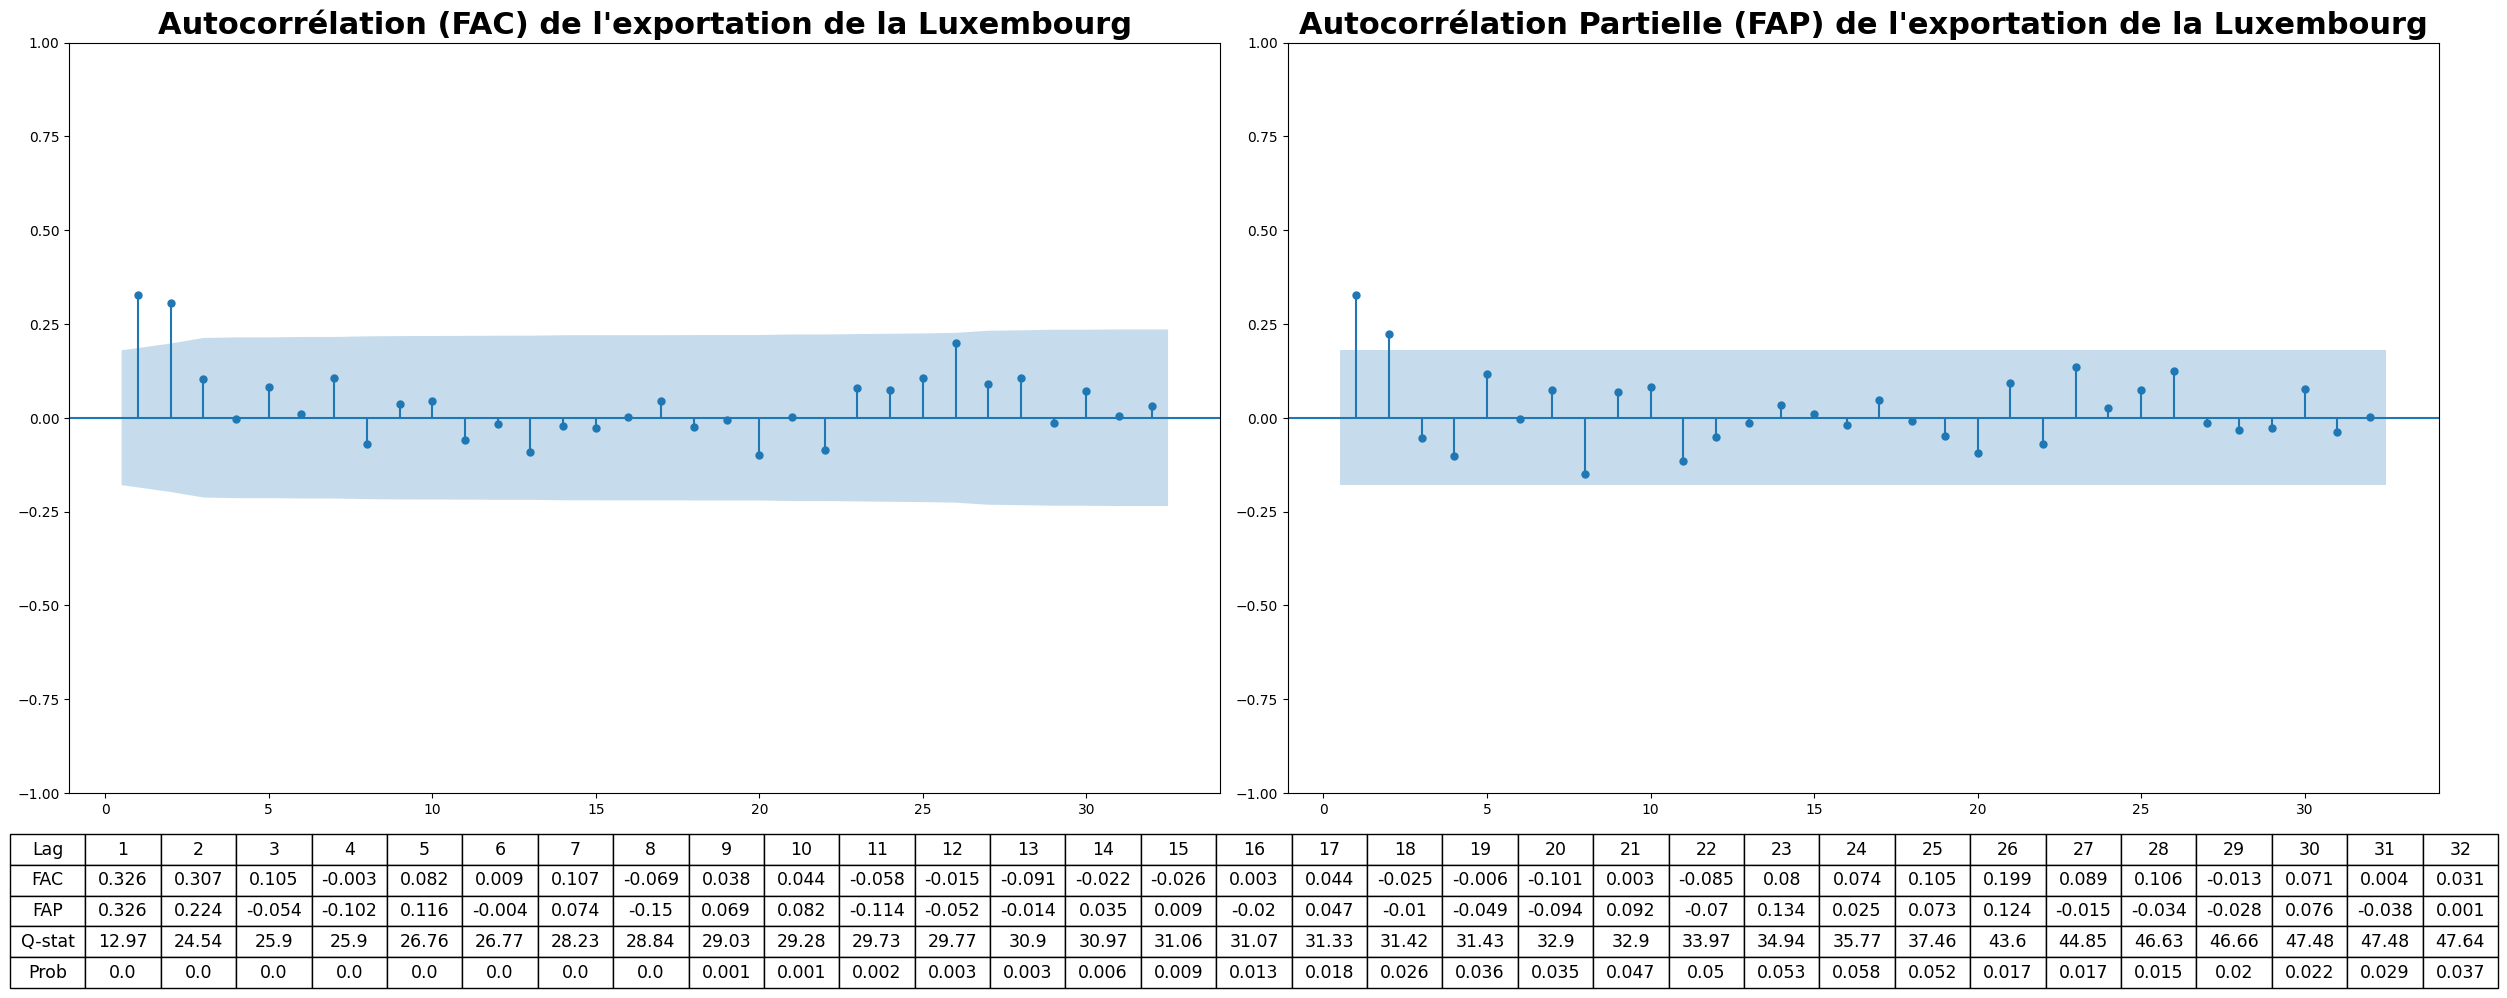

In [15]:
XDG = XTD.set_index("Lag").T
XDG = XDG.reset_index().rename(
    columns={"index": "Lag"}
)  # Important pour afficher FAC/FAP/etc
# Créer la figure avec GridSpec
fig = plt.figure(figsize=(25, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 3])
# Graphiques
ax0 = fig.add_subplot(gs[0, 0])
sm.graphics.tsa.plot_acf(
    X_diff,
    lags=32,
    zero=False,
    title="Autocorrélation (FAC) de l'exportation de la Luxembourg",
    ax=ax0,
)
ax0.set_title(
    "Autocorrélation (FAC) de l'exportation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)
ax1 = fig.add_subplot(gs[0, 1])
sm.graphics.tsa.plot_pacf(
    X_diff,
    lags=32,
    zero=False,
    title="Autocorrélation Partielle (FAP) de l'exportation de la Luxembourg",
    ax=ax1,
)
ax1.set_title(
    "Autocorrélation Partielle (FAP) de l'exportation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)
# Tableau en bas
ax2 = fig.add_subplot(gs[1, :])
ax2.axis("off")

table = ax2.table(
    cellText=XDG.values, colLabels=XDG.columns, cellLoc="center", loc="upper center"
)
table.scale(1.05, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(12.5)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "acf-pacf-x-diff.png", bbox_inches="tight")
plt.show()

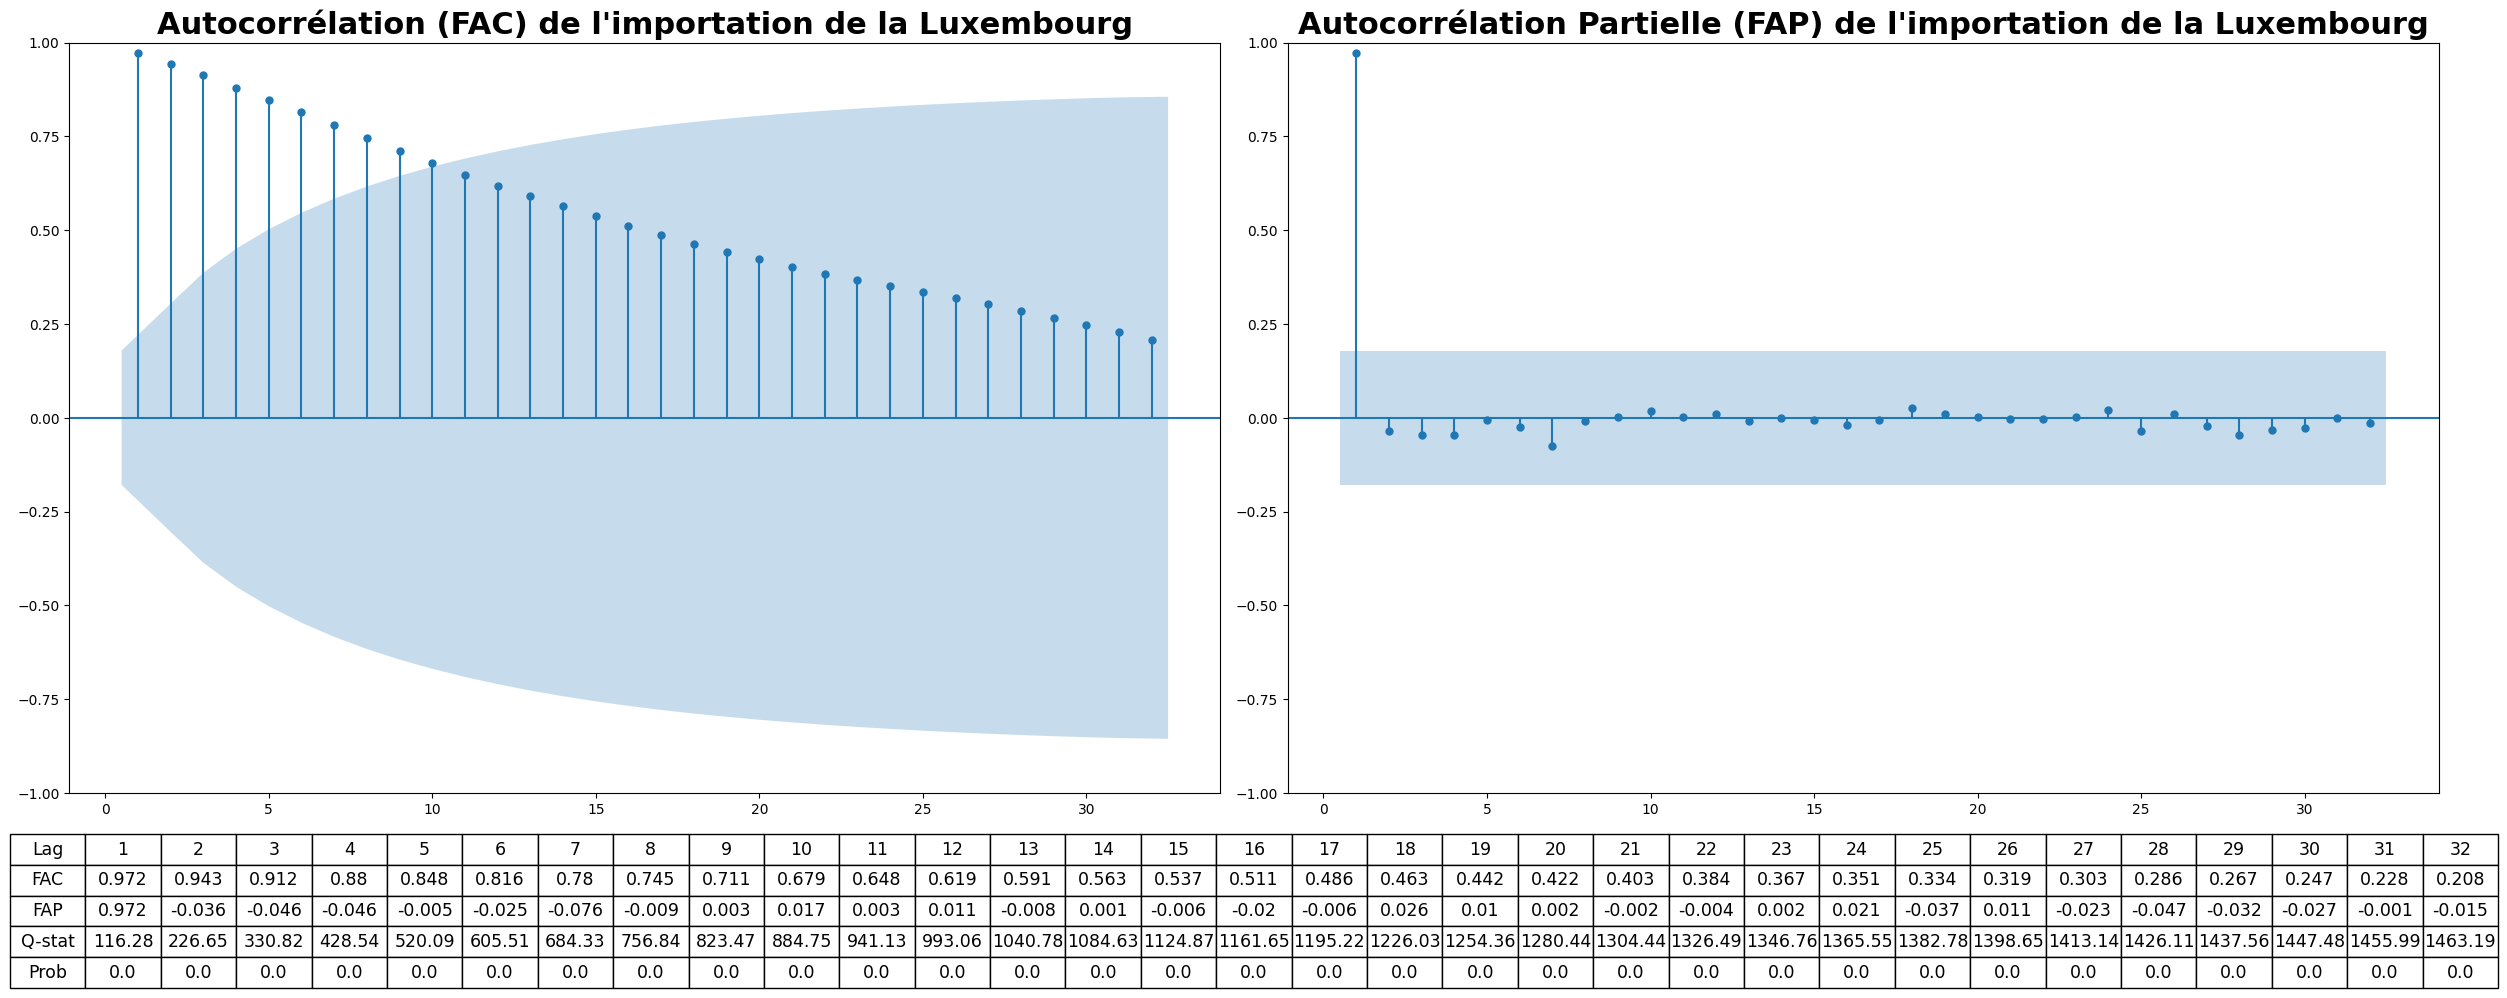

In [16]:
MG = MT.set_index("Lag").T
MG = MG.reset_index().rename(
    columns={"index": "Lag"}
)  # Important pour afficher FAC/FAP/etc
# Créer la figure avec GridSpec
fig = plt.figure(figsize=(25, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 3])
# Graphiques
ax0 = fig.add_subplot(gs[0, 0])
sm.graphics.tsa.plot_acf(
    M,
    lags=32,
    zero=False,
    title="Autocorrélation (FAC) de l'importation de la Luxembourg",
    ax=ax0,
)
ax0.set_title(
    "Autocorrélation (FAC) de l'importation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)
ax1 = fig.add_subplot(gs[0, 1])
sm.graphics.tsa.plot_pacf(
    M,
    lags=32,
    zero=False,
    title="Autocorrélation Partielle (FAP) de l'importation de la Luxembourg",
    ax=ax1,
)
ax1.set_title(
    "Autocorrélation Partielle (FAP) de l'importation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)

# Tableau en bas
ax2 = fig.add_subplot(gs[1, :])
ax2.axis("off")

table = ax2.table(
    cellText=MG.values, colLabels=MG.columns, cellLoc="center", loc="upper center"
)
table.scale(1.05, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(12.5)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "acf-pacf-m-level.png", bbox_inches="tight")
plt.show()

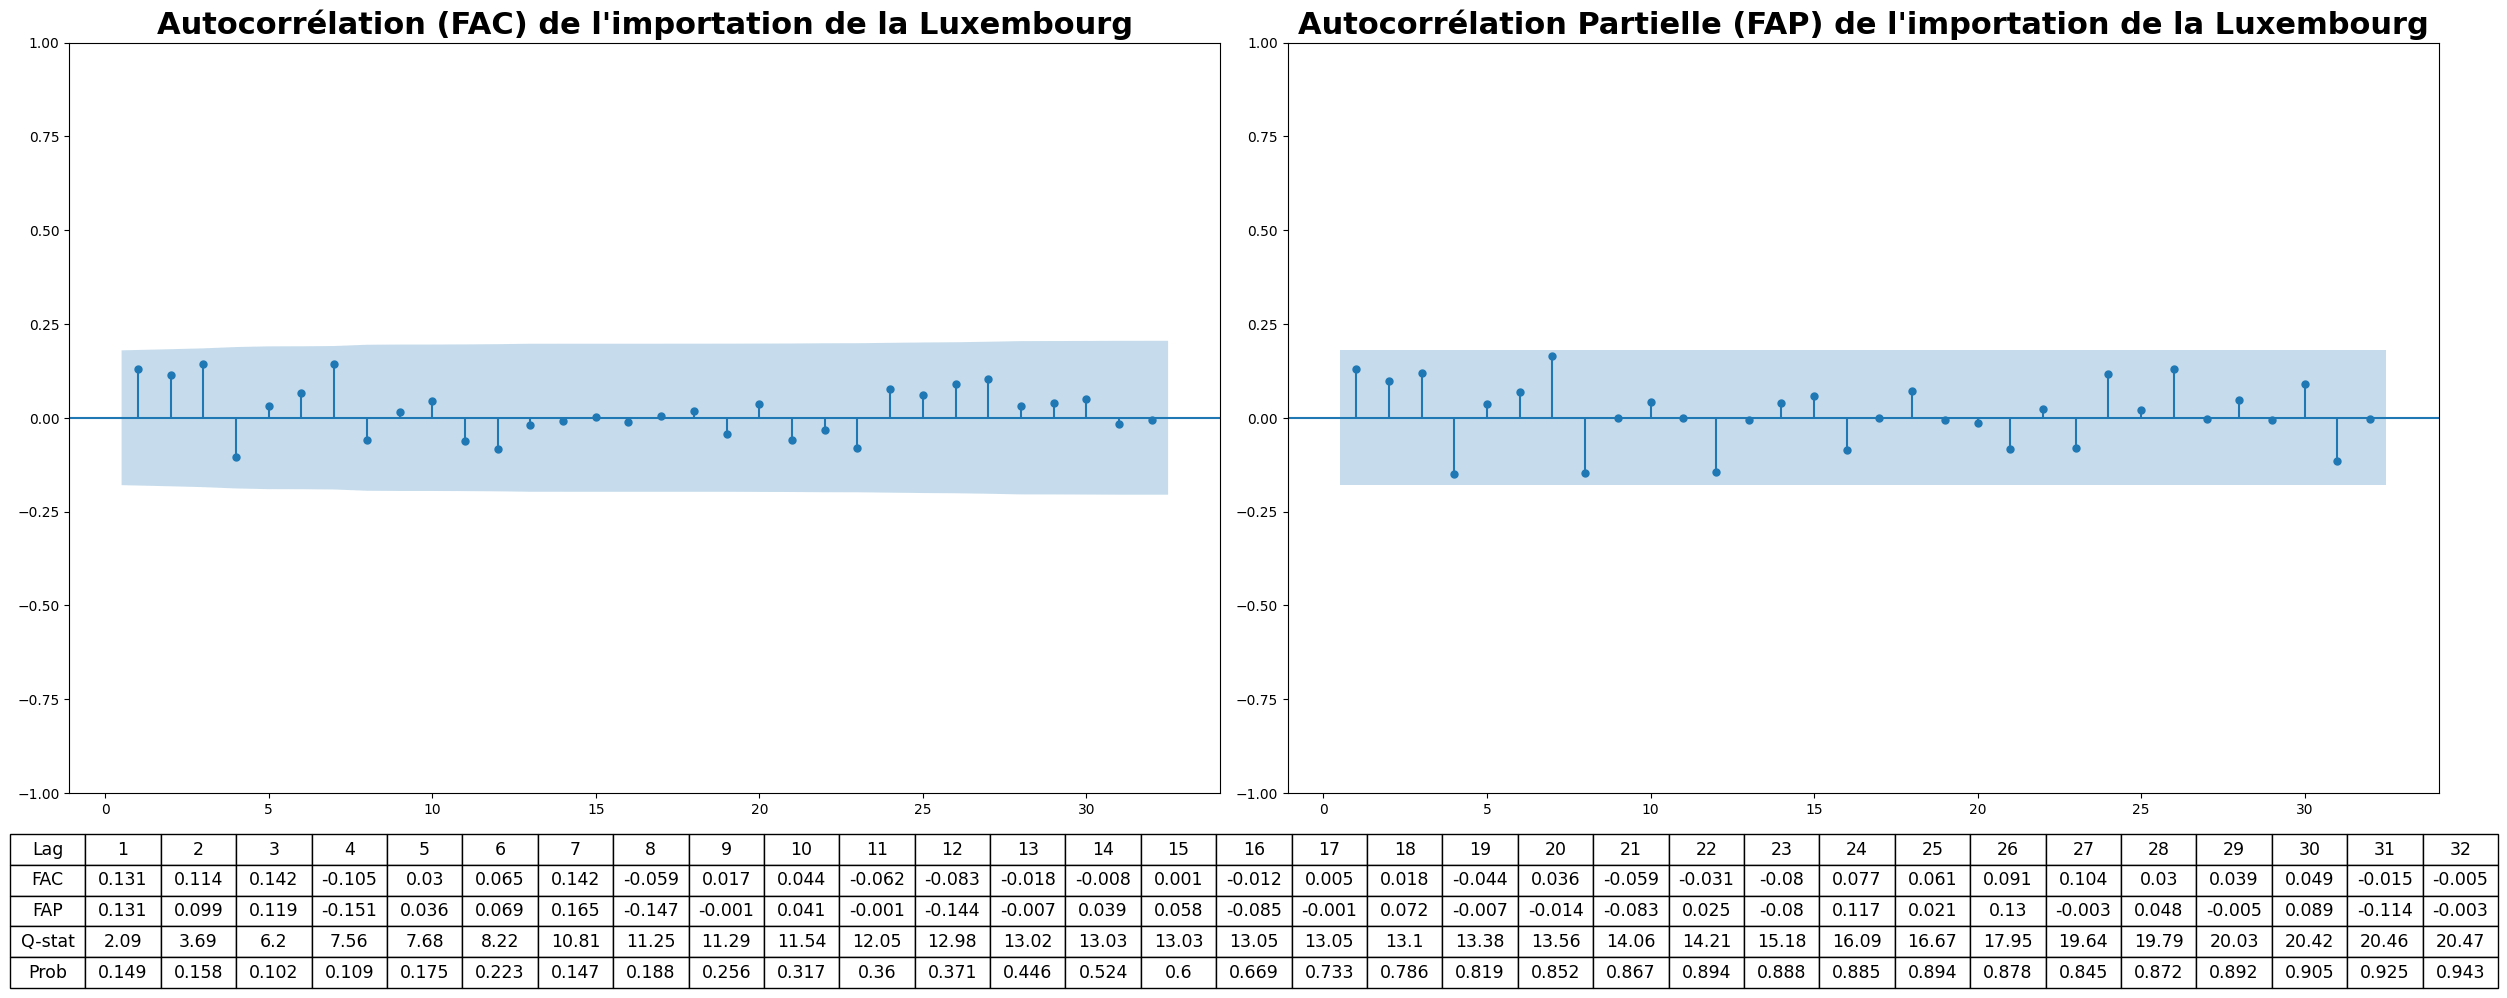

In [17]:
MDG = MTD.set_index("Lag").T
MDG = MDG.reset_index().rename(
    columns={"index": "Lag"}
)  # Important pour afficher FAC/FAP/etc
# Créer la figure avec GridSpec
fig = plt.figure(figsize=(25, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 3])
# Graphiques
ax0 = fig.add_subplot(gs[0, 0])
sm.graphics.tsa.plot_acf(
    M_diff,
    lags=32,
    zero=False,
    title="Autocorrélation (FAC) de l'exportation de la Luxembourg",
    ax=ax0,
)
ax0.set_title(
    "Autocorrélation (FAC) de l'importation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)

ax1 = fig.add_subplot(gs[0, 1])
sm.graphics.tsa.plot_pacf(
    M_diff,
    lags=32,
    zero=False,
    title="Autocorrélation Partielle (FAP) de l'exportation de la Luxembourg",
    ax=ax1,
)
ax1.set_title(
    "Autocorrélation Partielle (FAP) de l'importation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)
# Tableau en bas là
ax2 = fig.add_subplot(gs[1, :])
ax2.axis("off")

table = ax2.table(
    cellText=MDG.values, colLabels=MDG.columns, cellLoc="center", loc="upper center"
)
table.scale(1.05, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(12.5)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "acf-pacf-m-diff.png", bbox_inches="tight")
plt.show()

# PARTIE 2 : Modèle multivariée

## Causalité de Granger

In [18]:
XMD = XM.diff().fillna(0).rename(columns={"lnX": "ΔlnX", "lnM": "ΔlnM"})
VARXMD = VAR(XMD)

In [19]:
VARXMD_1 = VARXMD.fit(1)
with open(TABLE_DIR / "var-lag-selection-1.txt", "w") as f:
    f.write(str(VARXMD_1.summary()))
VARXMD_1.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 10, Sep, 2026
Time:                     20:45:18
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -15.0617
Nobs:                     119.000    HQIC:                  -15.1449
Log likelihood:           572.798    FPE:                2.50013e-07
AIC:                     -15.2018    Det(Omega_mle):     2.37868e-07
--------------------------------------------------------------------
Results for equation ΔlnX
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const           0.008045         0.002444            3.292           0.001
L1.ΔlnX         0.391514         0.130173            3.008           0.003
L1.ΔlnM        -0.068917         0.103334           -0.667           0.505

Results f

In [20]:
VARXMD_2 = VARXMD.fit(2)
with open(TABLE_DIR / "var-lag-selection-2.txt", "w") as f:
    f.write(str(VARXMD_2.summary()))
VARXMD_2.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 10, Sep, 2026
Time:                     20:45:18
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -15.0542
Nobs:                     118.000    HQIC:                  -15.1936
Log likelihood:           577.180    FPE:                2.29153e-07
AIC:                     -15.2890    Det(Omega_mle):     2.10901e-07
--------------------------------------------------------------------
Results for equation ΔlnX
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const           0.005731         0.002539            2.257           0.024
L1.ΔlnX         0.356955         0.129241            2.762           0.006
L1.ΔlnM        -0.116763         0.108140           -1.080           0.280
L2.ΔlnX   

In [21]:
VARXMD_3 = VARXMD.fit(3)
with open(TABLE_DIR / "var-lag-selection-3.txt", "w") as f:
    f.write(str(VARXMD_3.summary()))
VARXMD_3.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 10, Sep, 2026
Time:                     20:45:18
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -14.9347
Nobs:                     117.000    HQIC:                  -15.1310
Log likelihood:           574.983    FPE:                2.34708e-07
AIC:                     -15.2652    Det(Omega_mle):     2.08957e-07
--------------------------------------------------------------------
Results for equation ΔlnX
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const           0.005729         0.002659            2.155           0.031
L1.ΔlnX         0.344901         0.135823            2.539           0.011
L1.ΔlnM        -0.087520         0.114287           -0.766           0.444
L2.ΔlnX   

In [22]:
VARXMD_4 = VARXMD.fit(4)
with open(TABLE_DIR / "var-lag-selection-4.txt", "w") as f:
    f.write(str(VARXMD_4.summary()))
VARXMD_4.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 10, Sep, 2026
Time:                     20:45:18
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -14.8600
Nobs:                     116.000    HQIC:                  -15.1138
Log likelihood:           575.468    FPE:                2.29665e-07
AIC:                     -15.2873    Det(Omega_mle):     1.97784e-07
--------------------------------------------------------------------
Results for equation ΔlnX
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const           0.006973         0.002803            2.488           0.013
L1.ΔlnX         0.351349         0.140141            2.507           0.012
L1.ΔlnM        -0.088536         0.117188           -0.756           0.450
L2.ΔlnX   

In [23]:
VARXMD_2.test_causality("ΔlnX", ["ΔlnM"], kind="wald", signif=0.05).summary()

Test statistic,Critical value,p-value,df
2.074,5.991,0.354,2


In [24]:
VARXMD_2.test_causality("ΔlnX", ["ΔlnX"], kind="wald", signif=0.01).summary()

Test statistic,Critical value,p-value,df
9.072,9.210,0.011,2


In [25]:
VARXMD_2.test_causality("ΔlnM", ["ΔlnX"], kind="wald", signif=0.1).summary()

Test statistic,Critical value,p-value,df
34.82,4.605,0.000,2


In [26]:
VARXMD_2.test_causality("ΔlnM", ["ΔlnM"], kind="wald", signif=0.05).summary()

Test statistic,Critical value,p-value,df
14.17,5.991,0.001,2


In [27]:
GTXM = (
    VARXMD_2.test_causality("ΔlnX", ["ΔlnM"], kind="wald", signif=0.05)
    .summary()
    .as_text()
)
GTXX = (
    VARXMD_2.test_causality("ΔlnX", ["ΔlnX"], kind="wald", signif=0.01)
    .summary()
    .as_text()
)
GTMX = (
    VARXMD_2.test_causality("ΔlnM", ["ΔlnX"], kind="wald", signif=0.1)
    .summary()
    .as_text()
)
GTMM = (
    VARXMD_2.test_causality("ΔlnM", ["ΔlnM"], kind="wald", signif=0.05)
    .summary()
    .as_text()
)

# GTXM = M cause-t-il X ? / GTMX = X cause-t-il M ? / GTXX, GTMM = significativité des retards propres
tests_granger = {"m-to-x": GTXM, "x-to-x": GTXX, "x-to-m": GTMX, "m-to-m": GTMM}

for name, content in tests_granger.items():
    with open(TABLE_DIR / f"test-granger-{name}.txt", "w") as file:
        file.write(f"{content}\n")

In [28]:
Test = grangercausalitytests(XMD, 2, addconst=True)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.4448  , p=0.5061  , df_denom=116, df_num=1
ssr based chi2 test:   chi2=0.4563  , p=0.4994  , df=1
likelihood ratio test: chi2=0.4554  , p=0.4998  , df=1
parameter F test:         F=0.4448  , p=0.5061  , df_denom=116, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.0371  , p=0.3578  , df_denom=113, df_num=2
ssr based chi2 test:   chi2=2.1660  , p=0.3386  , df=2
likelihood ratio test: chi2=2.1464  , p=0.3419  , df=2
parameter F test:         F=1.0371  , p=0.3578  , df_denom=113, df_num=2


# PARTIE 3 : Cointégration

### MCO de la régression des exportations sur les  importations

In [29]:
x2 = sm.add_constant(M["M"])
y2 = X["X"]

modelXM = sm.OLS(y2, x2).fit()
print(modelXM.summary())
with open(TABLE_DIR / "model-cointegration-xm.txt", "w") as f:
    f.write(modelXM.summary().as_text())

                            OLS Regression Results                            
Dep. Variable:                      X   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 4.133e+04
Date:                Thu, 10 Sep 2026   Prob (F-statistic):          4.69e-152
Time:                        20:45:18   Log-Likelihood:                 280.83
No. Observations:                 120   AIC:                            -557.7
Df Residuals:                     118   BIC:                            -552.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8472      0.044     19.460      0.0

### Résidu du MCO Exp sur Imp

In [30]:
Residuxm = modelXM.resid

ResiduXM = pd.DataFrame({"Valeurs_ajustées": modelXM.fittedvalues, "u": Residuxm})

### MCO de la régression des importations sur les exportations

In [31]:
x1 = sm.add_constant(X["X"])
y1 = M["M"]

modelMX = sm.OLS(y1, x1).fit()
print(modelMX.summary())
with open(TABLE_DIR / "model-cointegration-mx.txt", "w") as f:
    f.write(modelMX.summary().as_text())

                            OLS Regression Results                            
Dep. Variable:                      M   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 4.133e+04
Date:                Thu, 10 Sep 2026   Prob (F-statistic):          4.69e-152
Time:                        20:45:18   Log-Likelihood:                 272.60
No. Observations:                 120   AIC:                            -541.2
Df Residuals:                     118   BIC:                            -535.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8791      0.051    -17.233      0.0

### Résidu du MCO Imp sur Exp

In [32]:
Residumx = modelMX.resid

ResiduMX = pd.DataFrame({"Valeurs_ajustées": modelMX.fittedvalues, "u": Residumx})

### Graphique des résidus

In [33]:
ResiduXMG = ResiduXM.drop("Valeurs_ajustées", axis=1)
ResiduXMGFlat = np.array(ResiduXMG).flatten()

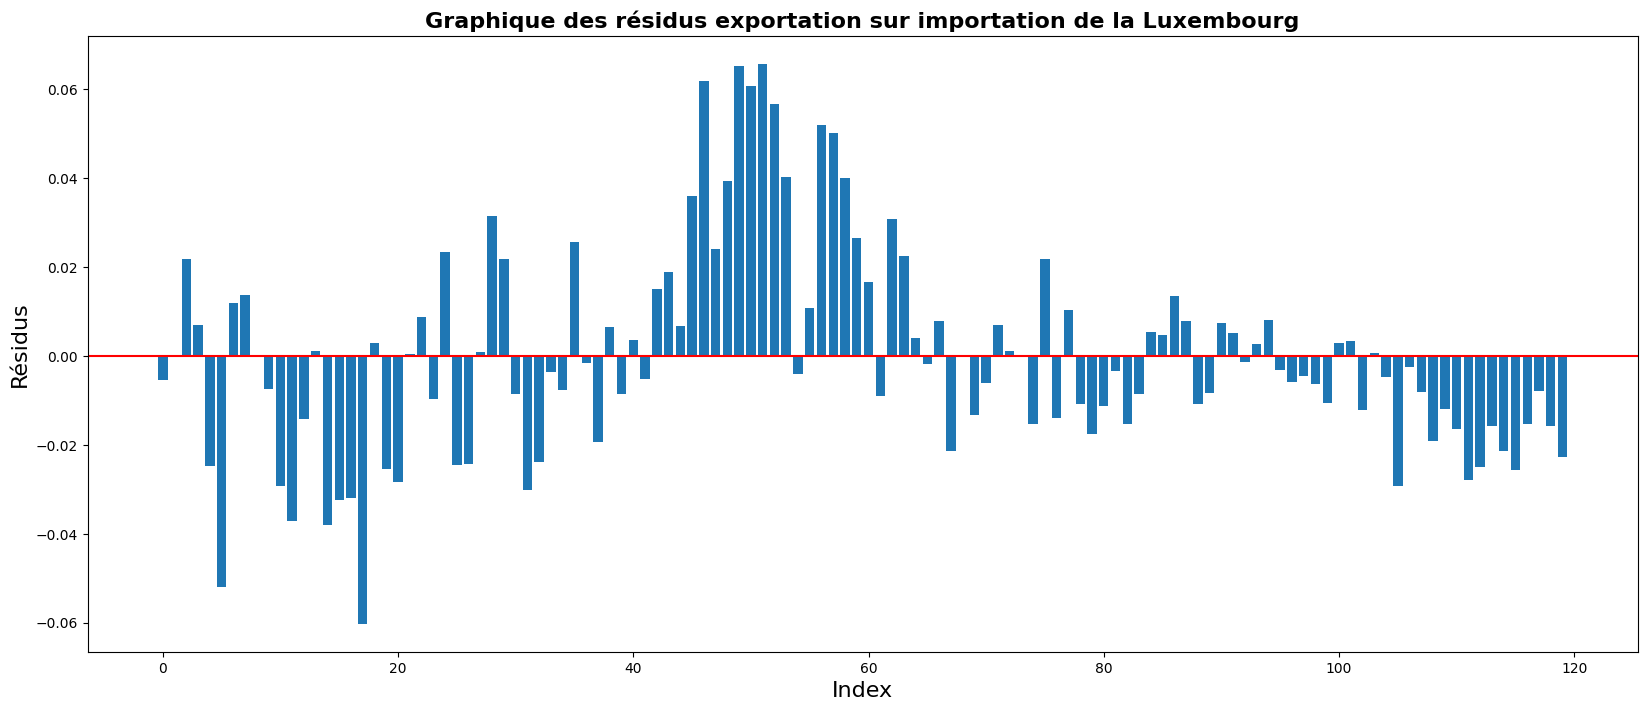

In [34]:
plt.figure(figsize=(20, 8))
plt.bar(range(len(ResiduXMGFlat)), ResiduXMGFlat)
plt.axhline(y=0, color="r", linestyle="-")
plt.xlabel("Index", fontsize=16)
plt.ylabel("Résidus", fontsize=16)
plt.title(
    "Graphique des résidus exportation sur importation de la Luxembourg",
    fontsize=16,
    fontweight="bold",
)
plt.savefig(FIGURE_DIR / "03-residus-cointegration-exp-imp.png", bbox_inches="tight")

In [35]:
ResiduMXG = ResiduMX.drop("Valeurs_ajustées", axis=1)
ResiduMXGFlat = np.array(ResiduMXG).flatten()

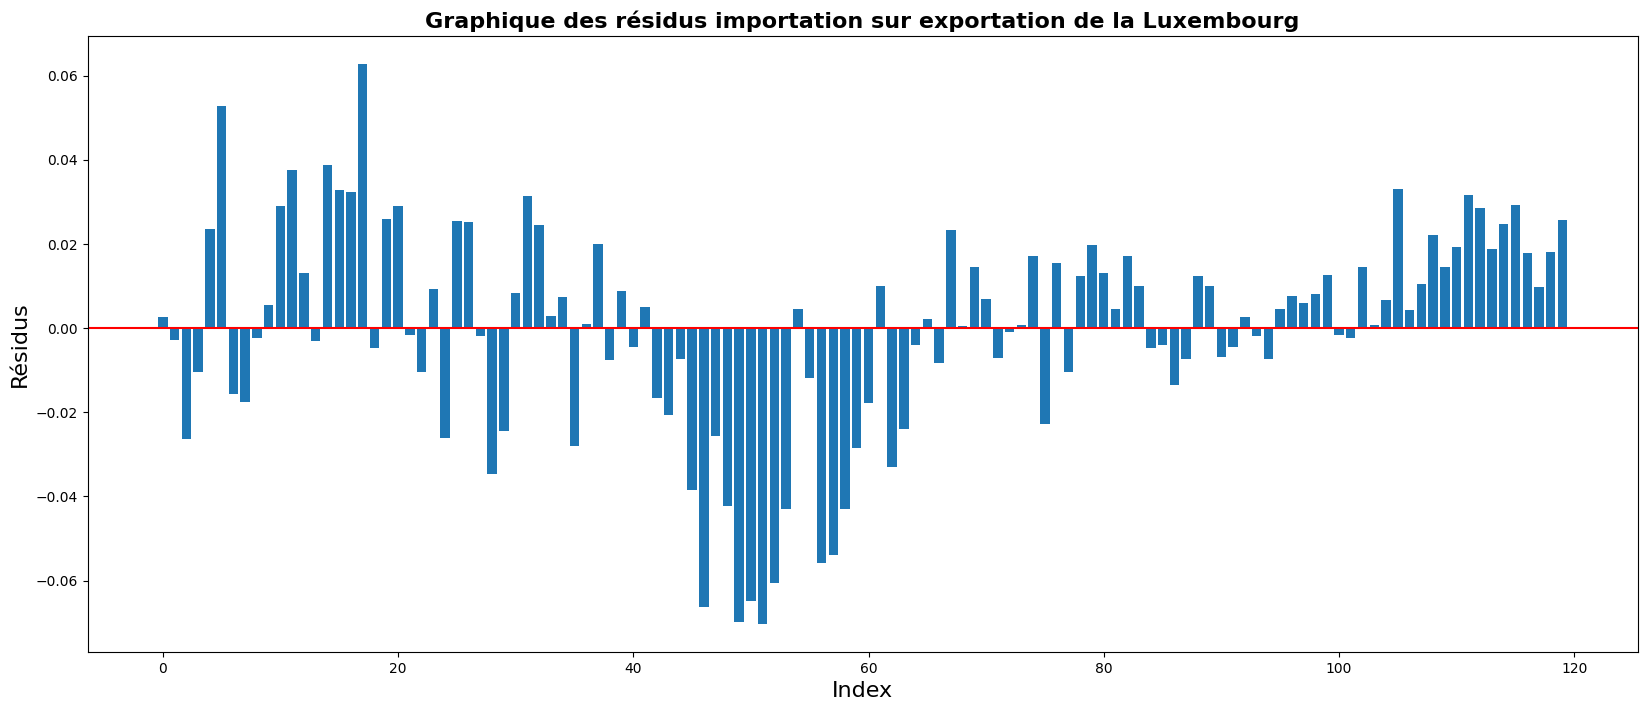

In [36]:
plt.figure(figsize=(20, 8))
plt.bar(range(len(ResiduMXGFlat)), ResiduMXGFlat)
plt.axhline(y=0, color="r", linestyle="-")
plt.xlabel("Index", fontsize=16)
plt.ylabel("Résidus", fontsize=16)
plt.title(
    "Graphique des résidus importation sur exportation de la Luxembourg",
    fontsize=16,
    fontweight="bold",
)
plt.savefig(FIGURE_DIR / "residus-cointegration-imp-exp.png", bbox_inches="tight")

### Tableau résidu

In [37]:
TRXM = ResiduXMG.rename(columns={"u": "uXM"})
TRMX = ResiduMXG.rename(columns={"u": "uMX"})
TableauRésXM = TRXM.join(TRMX)

In [38]:
TableauRésXM.to_csv(TABLE_DIR / "residus-xm-mx.csv", index=True)

with open(TABLE_DIR / "residus-xm-mx.txt", "a") as f:
    f.write(TableauRésXM.to_string(header=False, index=False))

### FAC et FAP des résidus ΔuXM et ΔuMX

In [39]:
ΔuXM_fac = acf(
    ResiduXMG,
    adjusted=0,
    nlags=32,
    qstat=True,
    fft=True,
    alpha=None,
    bartlett_confint=True,
    missing="none",
)
ΔuXMT = pd.DataFrame(ΔuXM_fac).T.rename(columns={0: "FAC", 1: "Q-stat", 2: "Prob"})
ΔuXM_fap = pacf(ResiduXMG, nlags=32, method="ywmle", alpha=None)
ΔuXTFAP = (
    pd.DataFrame(ΔuXM_fap).iloc[1:, :].reset_index(drop=True).rename(columns={0: "FAP"})
)
ΔuXMT.insert(1, "FAP", ΔuXTFAP)
ΔuXMT.iloc[:, 0] = ΔuXMT.iloc[:, 0].shift(-1)
ΔuXMT = ΔuXMT.drop(ΔuXMT.index[-1]).reset_index(drop=True)

ΔuXMT[["FAC", "FAP", "Prob"]] = ΔuXMT[["FAC", "FAP", "Prob"]].round(3)

ΔuXMT[["Q-stat"]] = ΔuXMT[["Q-stat"]].round(2)

ΔuXMT.insert(0, "Lag", range(1, len(ΔuXMT) + 1))

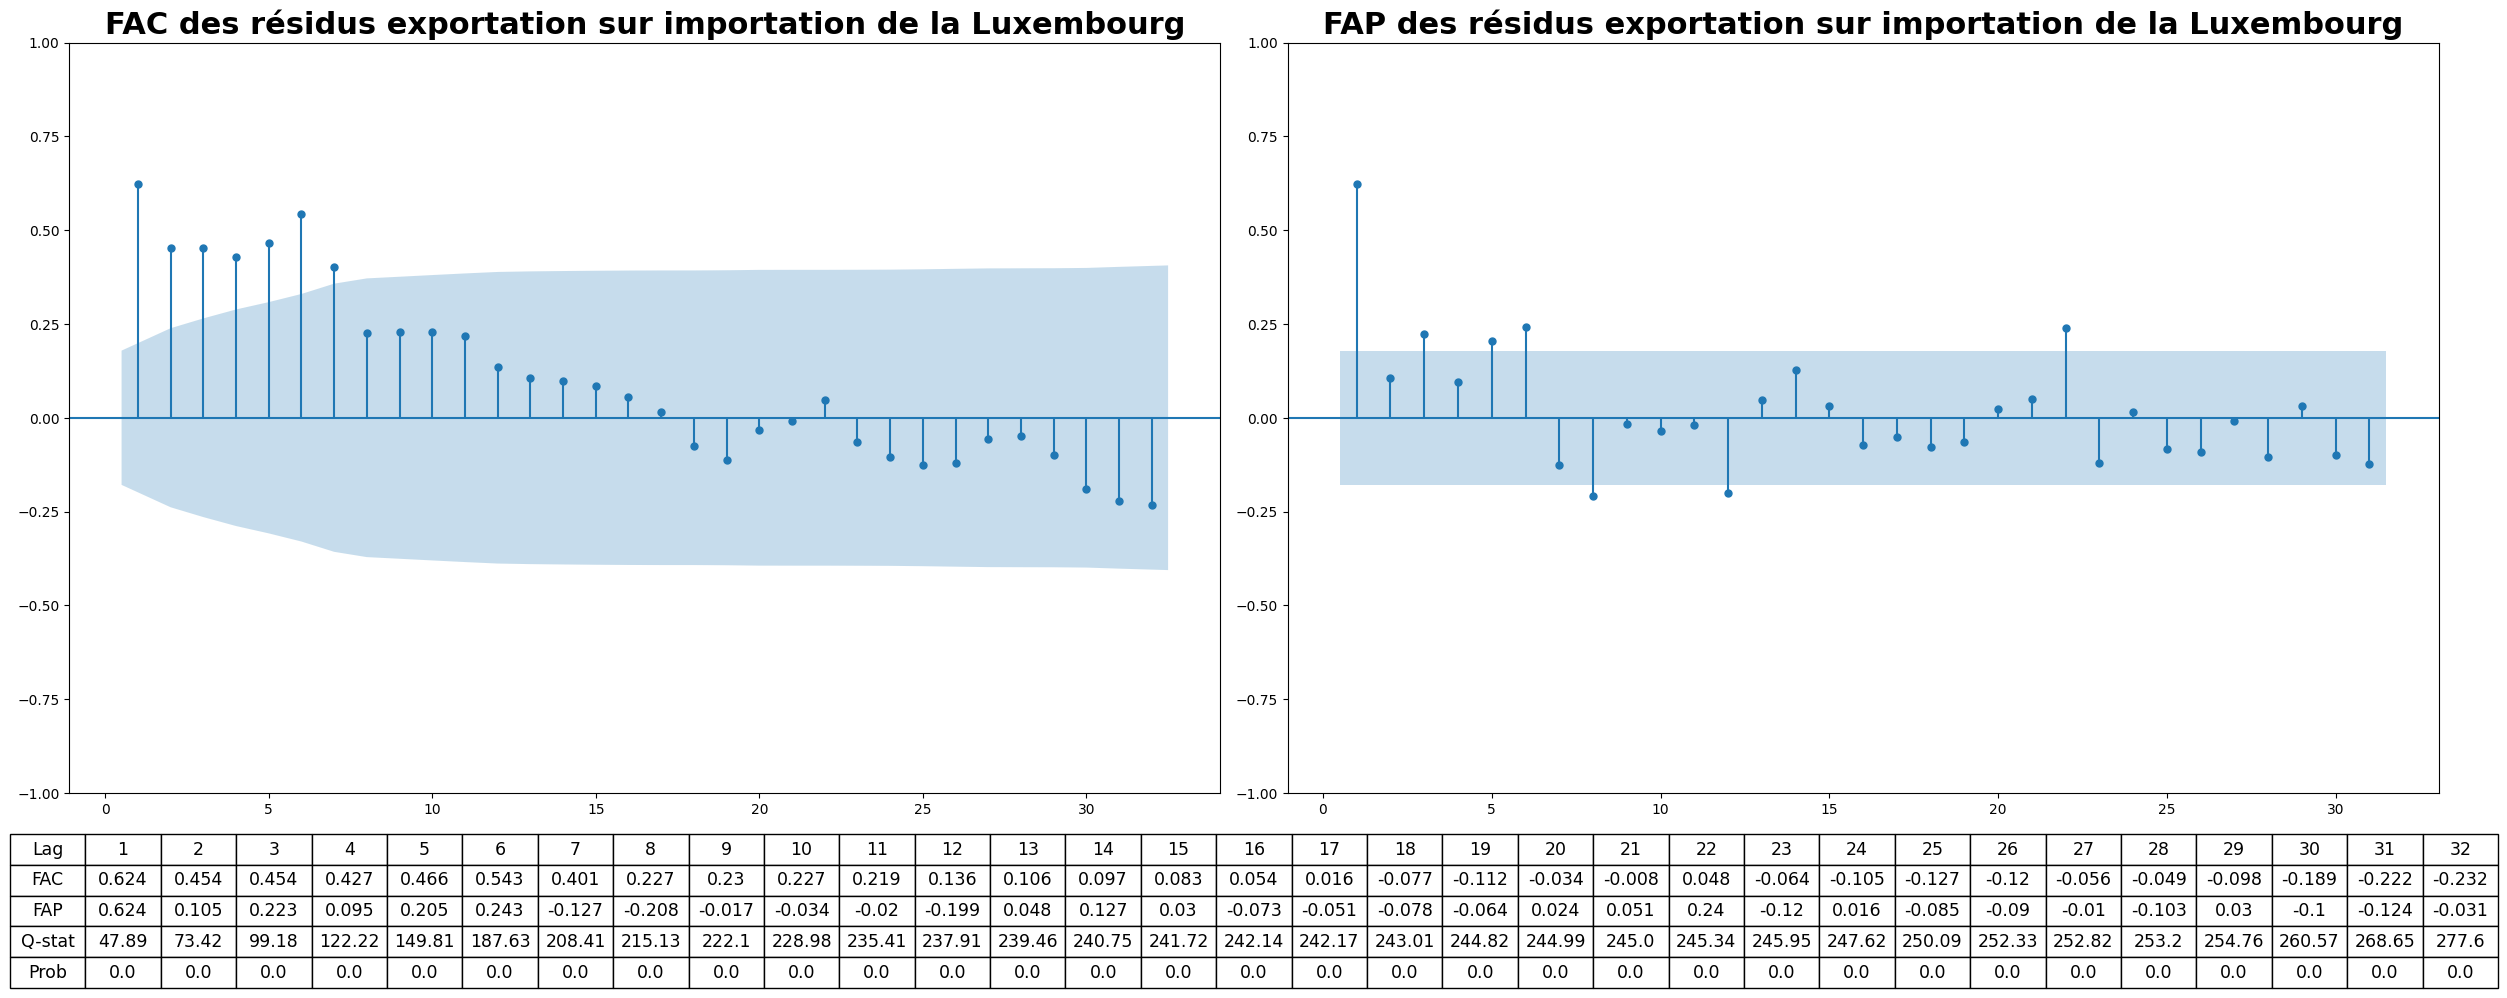

In [40]:
XG = ΔuXMT.set_index("Lag").T
XG = XG.reset_index().rename(
    columns={"index": "Lag"}
)  # Important pour afficher FAC/FAP/etc
# Créer la figure avec GridSpec
fig = plt.figure(figsize=(25, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 3])
# Graphiques
ax0 = fig.add_subplot(gs[0, 0])
sm.graphics.tsa.plot_acf(ResiduXMG, lags=32, zero=False, ax=ax0)
ax0.set_title(
    "FAC des résidus exportation sur importation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)
ax1 = fig.add_subplot(gs[0, 1])
sm.graphics.tsa.plot_pacf(ResiduXMG, lags=31, zero=False, ax=ax1)
ax1.set_title(
    "FAP des résidus exportation sur importation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)
# Tableau en bas
ax2 = fig.add_subplot(gs[1, :])
ax2.axis("off")

table = ax2.table(
    cellText=XG.values, colLabels=XG.columns, cellLoc="center", loc="upper center"
)
table.scale(1.05, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(12.5)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "acf-pacf-residus-xm.png", bbox_inches="tight")
plt.show()

In [41]:
ΔuMX_fac = acf(
    ResiduMXG,
    adjusted=0,
    nlags=32,
    qstat=True,
    fft=True,
    alpha=None,
    bartlett_confint=True,
    missing="none",
)
ΔuMXT = pd.DataFrame(ΔuMX_fac).T.rename(columns={0: "FAC", 1: "Q-stat", 2: "Prob"})
ΔuMX_fap = pacf(ResiduMXG, nlags=32, method="ywmle", alpha=None)
ΔuMXTFAP = (
    pd.DataFrame(ΔuMX_fap).iloc[1:, :].reset_index(drop=True).rename(columns={0: "FAP"})
)
ΔuMXT.insert(1, "FAP", ΔuMXTFAP)
ΔuMXT.iloc[:, 0] = ΔuMXT.iloc[:, 0].shift(-1)
ΔuMXT = ΔuMXT.drop(ΔuMXT.index[-1]).reset_index(drop=True)

ΔuMXT[["FAC", "FAP", "Prob"]] = ΔuMXT[["FAC", "FAP", "Prob"]].round(3)

ΔuMXT[["Q-stat"]] = ΔuMXT[["Q-stat"]].round(2)

ΔuMXT.insert(0, "Lag", range(1, len(ΔuMXT) + 1))

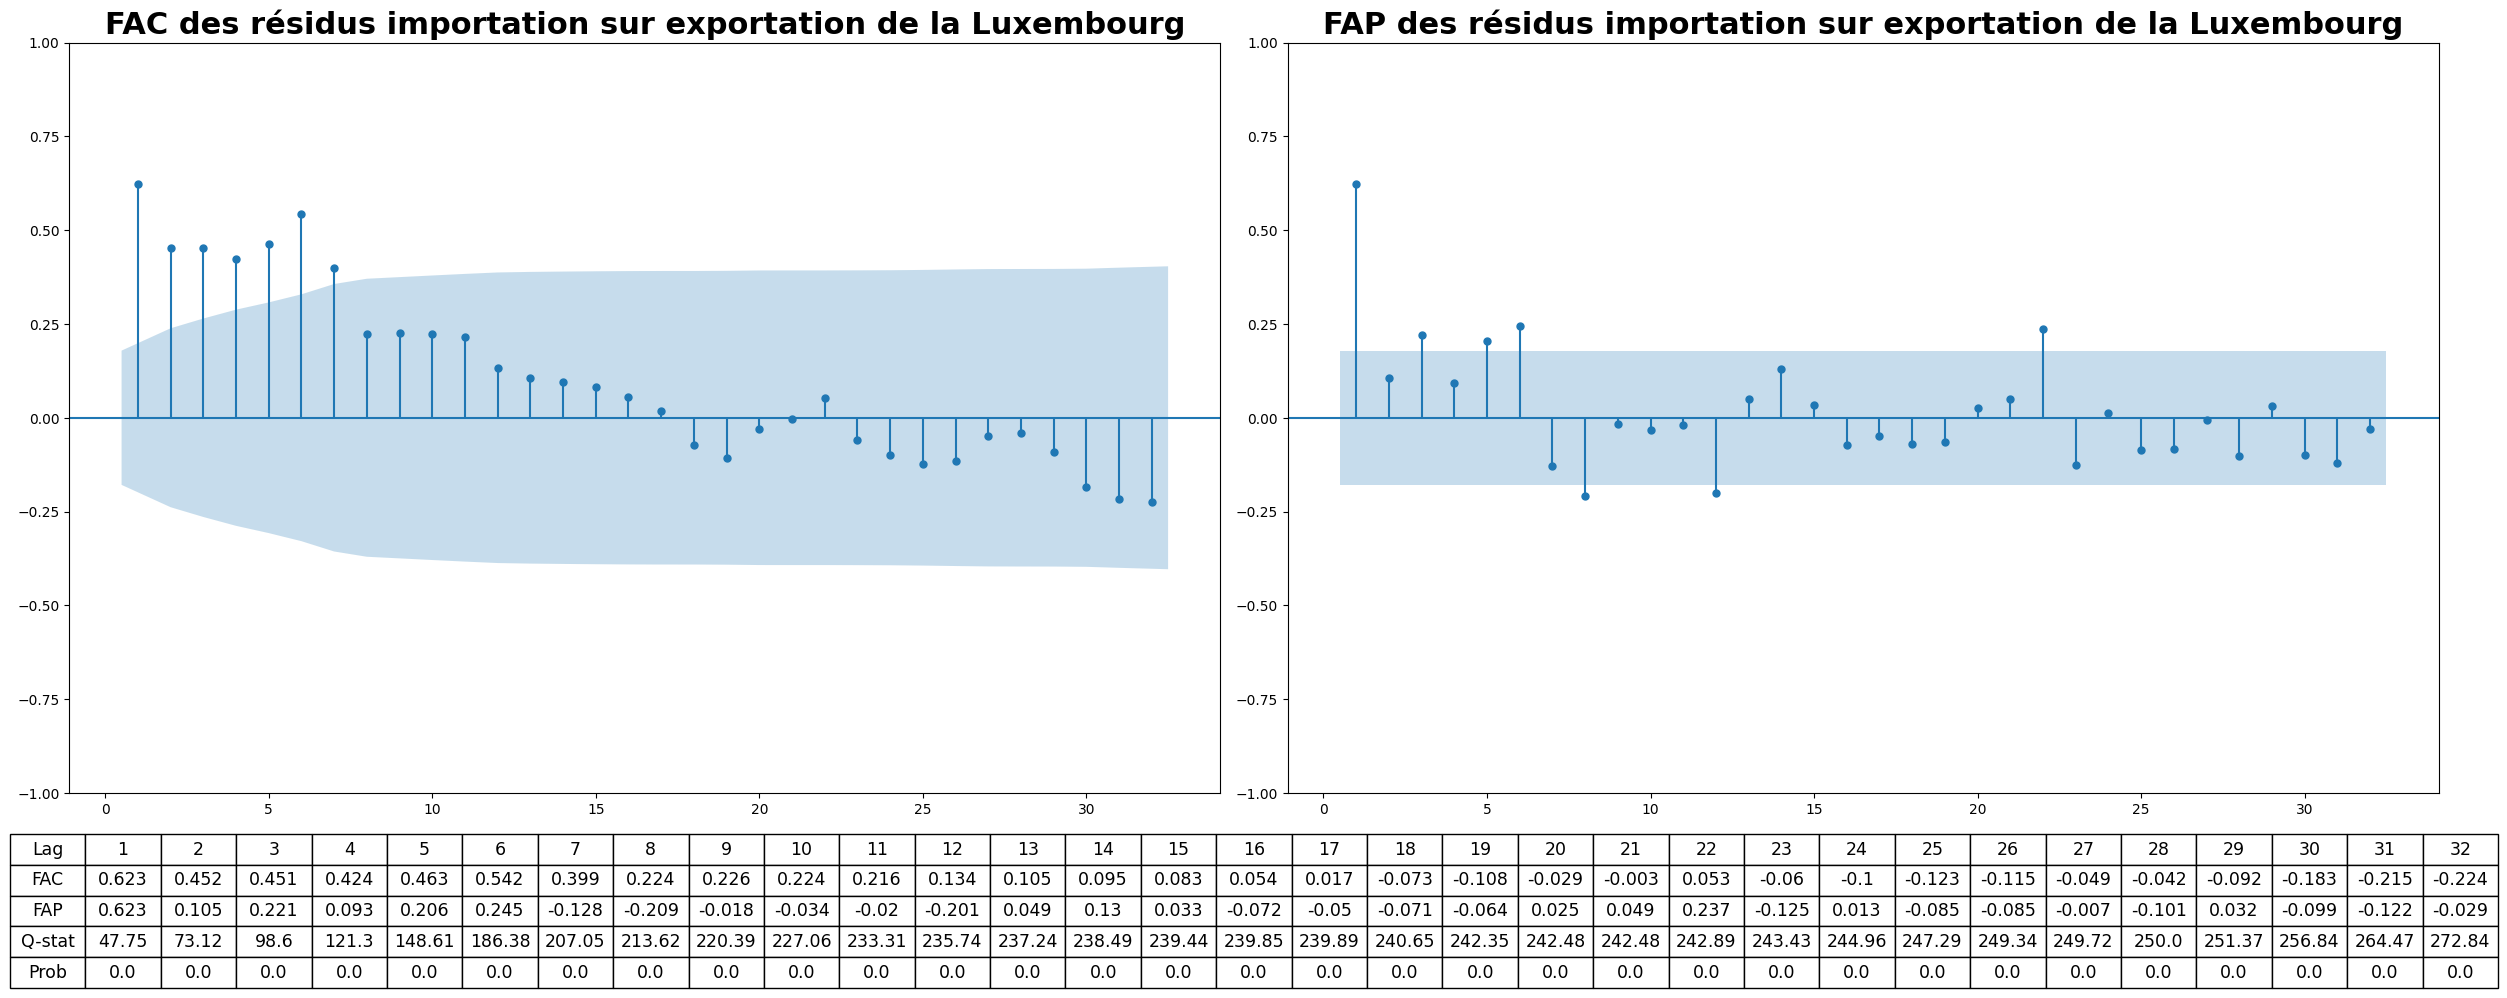

In [42]:
MG = ΔuMXT.set_index("Lag").T
MG = MG.reset_index().rename(
    columns={"index": "Lag"}
)  # Important pour afficher FAC/FAP/etc
# Créer la figure avec GridSpec
fig = plt.figure(figsize=(25, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 3])
# Graphiques
ax0 = fig.add_subplot(gs[0, 0])
sm.graphics.tsa.plot_acf(ResiduMXG, lags=32, zero=False, ax=ax0)
ax0.set_title(
    "FAC des résidus importation sur exportation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)
ax1 = fig.add_subplot(gs[0, 1])
sm.graphics.tsa.plot_pacf(ResiduMXG, lags=32, zero=False, ax=ax1)
ax1.set_title(
    "FAP des résidus importation sur exportation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)

# Tableau en bas
ax2 = fig.add_subplot(gs[1, :])
ax2.axis("off")

table = ax2.table(
    cellText=MG.values, colLabels=MG.columns, cellLoc="center", loc="upper center"
)
table.scale(1.05, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(12.5)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "acf-pacf-residus-mx.png", bbox_inches="tight")
plt.show()

### Regréssions

In [43]:
def retard(df, column_name, n):
    """
    Applique des décalages à une colonne d'un DataFrame et ajoute les colonnes décalées.

    :param df: DataFrame pandas
    :param column_name: Nom de la colonne à décaler
    :param n: Nombre de décalages à appliquer
    :return: DataFrame avec les colonnes décalées ajoutées
    """
    for i in range(1, n + 1):
        df[f"{column_name}(-{i})"] = df[column_name].shift(i, fill_value=0)
    return df

In [44]:
ResiduXM_D = ResiduXM.drop("Valeurs_ajustées", axis=1)
ResiduXM_D = ResiduXM_D.diff().fillna(0).rename(columns={"u": "Δu"})
ResiduXM_D = retard(ResiduXM_D, "Δu", 4)
ResiduXM_R = (
    ResiduXM.shift(fill_value=0)
    .rename(columns={"u": "u(-1)"})
    .drop("Valeurs_ajustées", axis=1)
)
ResiduXM_M = ResiduXM_R.join(ResiduXM_D, how="left").rename(columns={"Δu": "ΔuXM"})
print(ResiduXM_M)

            u(-1)      ΔuXM    Δu(-1)    Δu(-2)    Δu(-3)    Δu(-4)
1995-Q1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
1995-Q2 -0.005306  0.005120  0.000000  0.000000  0.000000  0.000000
1995-Q3 -0.000186  0.022025  0.005120  0.000000  0.000000  0.000000
1995-Q4  0.021839 -0.014930  0.022025  0.005120  0.000000  0.000000
1996-Q1  0.006909 -0.031561 -0.014930  0.022025  0.005120  0.000000
...           ...       ...       ...       ...       ...       ...
2023-Q4 -0.021309 -0.004373 -0.005464  0.009022  0.003032 -0.011514
2024-Q1 -0.025682  0.010435 -0.004373 -0.005464  0.009022  0.003032
2024-Q2 -0.015248  0.007402  0.010435 -0.004373 -0.005464  0.009022
2024-Q3 -0.007845 -0.007899  0.007402  0.010435 -0.004373 -0.005464
2024-Q4 -0.015744 -0.007031 -0.007899  0.007402  0.010435 -0.004373

[120 rows x 6 columns]


In [45]:
ResiduMX_D = ResiduMX.drop("Valeurs_ajustées", axis=1)
ResiduMX_D = ResiduMX_D.diff().fillna(0).rename(columns={"u": "Δu"})
ResiduMX_D = retard(ResiduMX_D, "Δu", 4)
ResiduMX_R = (
    ResiduMX.shift(fill_value=0)
    .rename(columns={"u": "u(-1)"})
    .drop("Valeurs_ajustées", axis=1)
)
ResiduMX_M = ResiduMX_R.join(ResiduMX_D, how="left").rename(columns={"Δu": "ΔuMX"})
print(ResiduMX_M)

            u(-1)      ΔuMX    Δu(-1)    Δu(-2)    Δu(-3)    Δu(-4)
1995-Q1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
1995-Q2  0.002703 -0.005471  0.000000  0.000000  0.000000  0.000000
1995-Q3 -0.002768 -0.023525 -0.005471  0.000000  0.000000  0.000000
1995-Q4 -0.026293  0.015990 -0.023525 -0.005471  0.000000  0.000000
1996-Q1 -0.010303  0.033911  0.015990 -0.023525 -0.005471  0.000000
...           ...       ...       ...       ...       ...       ...
2023-Q4  0.024692  0.004568  0.005859 -0.009662 -0.003219  0.012356
2024-Q1  0.029260 -0.011363  0.004568  0.005859 -0.009662 -0.003219
2024-Q2  0.017897 -0.008010 -0.011363  0.004568  0.005859 -0.009662
2024-Q3  0.009887  0.008311 -0.008010 -0.011363  0.004568  0.005859
2024-Q4  0.018198  0.007528  0.008311 -0.008010 -0.011363  0.004568

[120 rows x 6 columns]


## Nombre de retard à prendre pour la VECM

### Exportation sur Importation XM

In [46]:
XMy = ResiduXM_M["ΔuXM"]

In [47]:
XMx4 = ResiduXM_M[["u(-1)", "Δu(-1)", "Δu(-2)", "Δu(-3)", "Δu(-4)"]]
XMx4 = sm.add_constant(XMx4)

modelXM4 = sm.OLS(XMy, XMx4).fit()

In [48]:
XMx3 = ResiduXM_M[["u(-1)", "Δu(-1)", "Δu(-2)", "Δu(-3)"]]
XMx3 = sm.add_constant(XMx3)

modelXM3 = sm.OLS(XMy, XMx3).fit()

In [49]:
XMx2 = ResiduXM_M[["u(-1)", "Δu(-1)", "Δu(-2)"]]
XMx2 = sm.add_constant(XMx2)

modelXM2 = sm.OLS(XMy, XMx2).fit()

In [50]:
XMx1 = ResiduXM_M[["u(-1)", "Δu(-1)"]]
XMx1 = sm.add_constant(XMx1)

modelXM1 = sm.OLS(XMy, XMx1).fit()

In [51]:
XMx0 = ResiduXM_M[["u(-1)"]]
XMx0 = sm.add_constant(XMx0)

modelXM0 = sm.OLS(XMy, XMx0).fit()

### Importation sur Exportation MX

In [52]:
MXy = ResiduMX_M["ΔuMX"]

In [53]:
MXx4 = ResiduMX_M[["u(-1)", "Δu(-1)", "Δu(-2)", "Δu(-3)", "Δu(-4)"]]
MXx4 = sm.add_constant(MXx4)

modelMX4 = sm.OLS(MXy, MXx4).fit()

In [54]:
MXx3 = ResiduMX_M[["u(-1)", "Δu(-1)", "Δu(-2)", "Δu(-3)"]]
MXx3 = sm.add_constant(MXx3)

modelMX3 = sm.OLS(MXy, MXx3).fit()

In [55]:
MXx2 = ResiduMX_M[["u(-1)", "Δu(-1)", "Δu(-2)"]]
MXx2 = sm.add_constant(MXx2)

modelMX2 = sm.OLS(MXy, MXx2).fit()

In [56]:
MXx1 = ResiduMX_M[["u(-1)", "Δu(-1)"]]
MXx1 = sm.add_constant(MXx1)

modelMX1 = sm.OLS(MXy, MXx1).fit()

In [57]:
MXx0 = ResiduMX_M[["u(-1)"]]
MXx0 = sm.add_constant(MXx0)

modelMX0 = sm.OLS(MXy, MXx0).fit()

In [58]:
for i in range(5):
    model_name = f"modelXM{i}"
    file_name = f"model-lag-selection-xm-{i}.txt"
    current_model = globals()[model_name]
    text = current_model.summary().as_text()
    with open(TABLE_DIR / file_name, "w") as file:
        file.write(text)

    print(f"Le modèle {model_name} a été sauvegardé dans {file_name}")

Le modèle modelXM0 a été sauvegardé dans model-lag-selection-xm-0.txt
Le modèle modelXM1 a été sauvegardé dans model-lag-selection-xm-1.txt
Le modèle modelXM2 a été sauvegardé dans model-lag-selection-xm-2.txt
Le modèle modelXM3 a été sauvegardé dans model-lag-selection-xm-3.txt
Le modèle modelXM4 a été sauvegardé dans model-lag-selection-xm-4.txt


In [59]:
for i in range(5):
    model_name = f"modelMX{i}"
    file_name = f"model-lag-selection-mx-{i}.txt"
    current_model = globals()[model_name]
    text = current_model.summary().as_text()
    with open(TABLE_DIR / file_name, "w") as file:
        file.write(text)

    print(f"Le modèle {model_name} a été sauvegardé dans {file_name}")

Le modèle modelMX0 a été sauvegardé dans model-lag-selection-mx-0.txt
Le modèle modelMX1 a été sauvegardé dans model-lag-selection-mx-1.txt
Le modèle modelMX2 a été sauvegardé dans model-lag-selection-mx-2.txt
Le modèle modelMX3 a été sauvegardé dans model-lag-selection-mx-3.txt
Le modèle modelMX4 a été sauvegardé dans model-lag-selection-mx-4.txt


In [60]:
from statsmodels.tsa.vector_ar.vecm import VECM

serie = pd.concat([X, M], axis=1)
serie.columns = ["logX", "logM"]

vecm = VECM(serie, k_ar_diff=2, coint_rank=1, deterministic="co")
vecm_res = vecm.fit()
print(vecm_res.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation logX
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2322      0.101      2.295      0.022       0.034       0.430
L1.logX        0.4642      0.133      3.491      0.000       0.204       0.725
L1.logM       -0.2406      0.118     -2.041      0.041      -0.472      -0.010
L2.logX        0.2759      0.141      1.958      0.050      -0.000       0.552
L2.logM       -0.0211      0.108     -0.195      0.845      -0.233       0.191
Det. terms outside the coint. relation & lagged endog. parameters for equation logM
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0095      0.124      0.077      0.939      -0.233       0.252
L1.logX        0.8115      0.162      4.99

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


In [61]:
text = vecm_res.summary().as_text()
with open(TABLE_DIR / "vecm.txt", "w") as file:
    file.write(text)

## Partie 4

### Prévision

In [62]:
model = VECM(serie, k_ar_diff=2, coint_rank=1, deterministic="co")
model_fit = model.fit()

# Get the last `k_ar` observations (model's lag order)
lag_order = model.k_ar_diff
last_obs = serie.values[-lag_order:]


forecast = vecm_res.predict(steps=8)


forecast_df = pd.DataFrame(forecast, columns=serie.columns)

print(forecast_df)

        logX       logM
0  10.105709   9.947834
1  10.112471   9.951982
2  10.120180   9.961522
3  10.130669   9.971925
4  10.142171   9.983336
5  10.154412   9.996329
6  10.166791  10.009456
7  10.179286  10.022626


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


In [63]:
# Formater le dataframe forecast_df comme serie

# Générer la liste des nouveaux labels
quarters = [f"{year}-Q{quarter}" for year in [2025, 2026] for quarter in range(1, 5)]

# Affecter cette liste comme nouvel index
forecast_df.index = quarters

# Vérifier le résultat
print(forecast_df)

              logX       logM
2025-Q1  10.105709   9.947834
2025-Q2  10.112471   9.951982
2025-Q3  10.120180   9.961522
2025-Q4  10.130669   9.971925
2026-Q1  10.142171   9.983336
2026-Q2  10.154412   9.996329
2026-Q3  10.166791  10.009456
2026-Q4  10.179286  10.022626


/var/folders/p4/c_5q0_7x3ps5z6_phh6r8cb80000gn/T/ipykernel_19632/3664472599.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  serie_exp.index = pd.to_datetime(serie_exp.index)
/var/folders/p4/c_5q0_7x3ps5z6_phh6r8cb80000gn/T/ipykernel_19632/3664472599.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  forecast_exp.index = pd.to_datetime(forecast_exp.index)


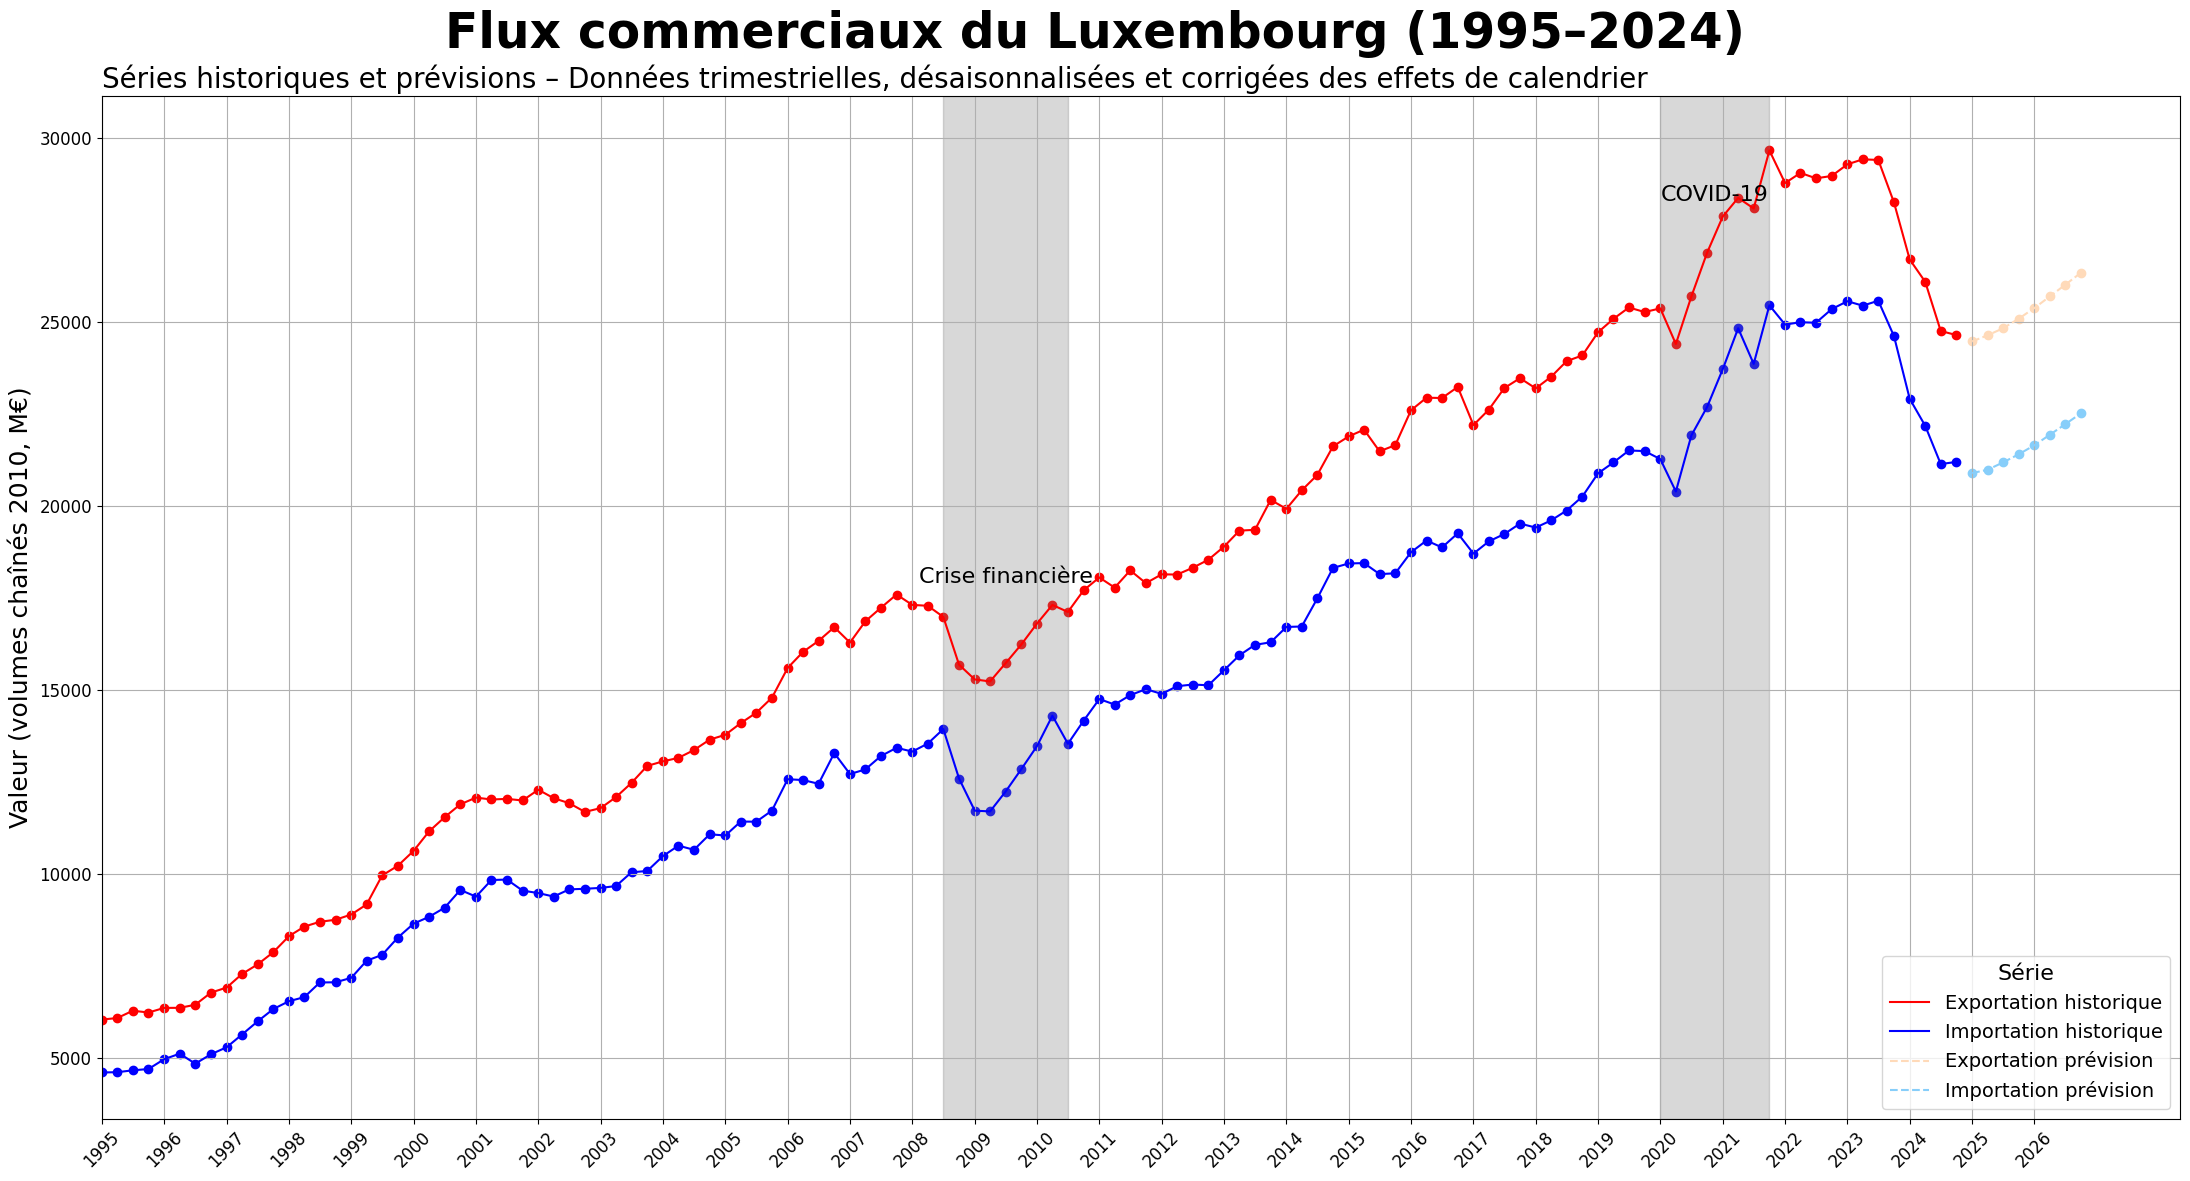

In [64]:
# Même graphique mais en mieux

# Exponentiation des séries
serie_exp = serie.copy()
serie_exp["logX"] = np.exp(serie["logX"])
serie_exp["logM"] = np.exp(serie["logM"])

forecast_exp = forecast_df.copy()
forecast_exp["logX"] = np.exp(forecast_df["logX"])
forecast_exp["logM"] = np.exp(forecast_df["logM"])

# S'assurer que l'index est bien en datetime
serie_exp.index = pd.to_datetime(serie_exp.index)
forecast_exp.index = pd.to_datetime(forecast_exp.index)

# Fusion des index pour définir les ticks
full_index = serie_exp.index.union(forecast_exp.index)

# Création de la figure
plt.figure(figsize=(22, 12))

# Courbes historiques
plt.plot(
    serie_exp.index,
    serie_exp["logX"],
    label="Exportation historique",
    color="red",
    linestyle="-",
)
plt.plot(
    serie_exp.index,
    serie_exp["logM"],
    label="Importation historique",
    color="blue",
    linestyle="-",
)

# Courbes prévisionnelles
plt.plot(
    forecast_exp.index,
    forecast_exp["logX"],
    label="Exportation prévision",
    color="peachpuff",
    linestyle="--",
)
plt.plot(
    forecast_exp.index,
    forecast_exp["logM"],
    label="Importation prévision",
    color="lightskyblue",
    linestyle="--",
)

# Points historiques
plt.scatter(serie_exp.index, serie_exp["logX"], color="red")
plt.scatter(serie_exp.index, serie_exp["logM"], color="blue")

# Points prévisionnels
plt.scatter(forecast_exp.index, forecast_exp["logX"], color="peachpuff")
plt.scatter(forecast_exp.index, forecast_exp["logM"], color="lightskyblue")

# Définir la hauteur max pour annotations
y_max = max(
    serie_exp[["logX", "logM"]].max().max(), forecast_exp[["logX", "logM"]].max().max()
)
plt.ylim(top=y_max * 1.05)

# Zones grisées pour les crises
crise_fin_start = pd.Timestamp("2008-07-01")
crise_fin_end = pd.Timestamp("2010-06-30")
covid_start = pd.Timestamp("2020-01-01")
covid_end = pd.Timestamp("2021-09-30")

plt.axvspan(crise_fin_start, crise_fin_end, color="grey", alpha=0.3)
plt.axvspan(covid_start, covid_end, color="grey", alpha=0.3)

# Annotations des crises
plt.text(
    x=crise_fin_start + (crise_fin_end - crise_fin_start) / 2,
    y=y_max * 0.6,
    s="Crise financière",
    fontsize=16,
    ha="center",
    va="bottom",
    color="black",
)

plt.text(
    x=covid_start + (covid_end - covid_start) / 2,
    y=y_max * 0.95,
    s="COVID-19",
    fontsize=16,
    ha="center",
    va="bottom",
    color="black",
)

# Titres et labels
plt.xlabel(None)
plt.ylabel("Valeur (volumes chaînés 2010, M€)", fontsize=18)
plt.title(
    "Séries historiques et prévisions – Données trimestrielles, désaisonnalisées et corrigées des effets de calendrier",
    fontsize=20,
    loc="left",
)
plt.suptitle(
    "Flux commerciaux du Luxembourg (1995–2024)", fontsize=35, fontweight="bold"
)

# Légende
plt.legend(
    title="Série",
    title_fontsize=16,
    fontsize=14,
    loc="lower right",
    bbox_to_anchor=(1, 0),
)

# Grille
plt.grid(True)

# Axe des x – affichage des années
plt.xlim(left=pd.Timestamp("1995-01-01"))
plt.xticks(
    pd.date_range(start="1995-01-01", end=full_index.max(), freq="YS"),
    fontsize=12,
    rotation=45,
)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Axe des y
plt.yticks(fontsize=12)

# Affichage
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04-previsions-vecm.png", bbox_inches="tight")
plt.show()

### Comment présenter les résultats en tableau ?

In [65]:
forecast_exp.columns = ["Exportation", "Importation"]
forecast_exp = forecast_exp.round(2)

# Renommer l’index s’il a un sens (optionnel)
forecast_exp.index.name = "Annee"  # ou "Ligne", "Index", etc.

# Convertir en HTML avec les lignes (index)
html_table = forecast_exp.to_html(index=True)

# Sauvegarder dans un fichier HTML
with open(TABLE_DIR / "forecast.html", "w") as f:
    f.write(html_table)

### Taux de croissance

In [66]:
# Calculer le taux de croissance pour les variables prévisionnelles en niveau
growth_rates = forecast_exp[["Exportation", "Importation"]].pct_change()

# Renommer les colonnes pour refléter qu'il s'agit de taux de croissance
growth_rates.columns = ["growth_X", "growth_M"]

# Afficher les résultats
print(growth_rates)

growth_rates_percent = growth_rates * 100

# Afficher les résultats
print(growth_rates_percent)

            growth_X  growth_M
Annee                         
2025-01-01       NaN       NaN
2025-04-01  0.006784  0.004157
2025-07-01  0.007740  0.009585
2025-10-01  0.010544  0.010458
2026-01-01  0.011568  0.011477
2026-04-01  0.012316  0.013077
2026-07-01  0.012456  0.013214
2026-10-01  0.012574  0.013257
            growth_X  growth_M
Annee                         
2025-01-01       NaN       NaN
2025-04-01  0.678447  0.415700
2025-07-01  0.773963  0.958522
2025-10-01  1.054420  1.045765
2026-01-01  1.156839  1.147657
2026-04-01  1.231552  1.307746
2026-07-01  1.245592  1.321395
2026-10-01  1.257434  1.325659


In [67]:
growth_rates_percent = growth_rates_percent.round(2)

# Renommer l’index s’il a un sens (optionnel)
growth_rates_percent.index.name = "Annee"  # ou "Ligne", "Index", etc.

# Convertir en HTML avec les lignes (index)
html_table = growth_rates_percent.to_html(index=True)

# Sauvegarder dans un fichier HTML
with open(TABLE_DIR / "forecast-growth-rate.html", "w") as f:
    f.write(html_table)

# <center>Fin